# Cross-Domain Grad-CAM Localisation Study — corrected pipeline (v2)

This notebook replaces `Cross-Domain_Medical_Imaging_Transfer_Learning.ipynb` (v1). **Do not reuse any v1 number** — v1 contained bugs that invalidate its accuracy and IoU results (explained in each cell's *"What was wrong in v1"* note).

**How to run:** `Kernel → Restart & Run All`, top to bottom, once. Every number and figure is written to `outputs/v2_corrected/` and every number in the paper must be copied from `paper_numbers.json` / the CSV tables — never typed by hand.

| # | v1 problem | Effect | Fixed in |
|---|---|---|---|
| 1 | Images scaled to [0,1] **and then** `resnet50.preprocess_input` (expects 0–255) | Backbone saw near-constant images; skin/chest models ≈ majority-class predictors | Cell 2 |
| 2 | `unfreeze_model()` never found a nested ResNet, so **Stage 2 fine-tuned nothing** | Paper's "final 40 layers unfrozen" was false | Cell 5 |
| 3 | Chest IoU images taken from the full pool (≈80 % were training/val images); image-level split with patient overlap | Data leakage in the headline result | Cell 3 |
| 4 | Grad-CAM on the *predicted* class, from *softmax* | Correct (Disease map) vs wrong (Normal map) compare different, sign-flipped targets — reviewer #3 | Cell 8 |
| 5 | ISIC CSVs read with a header → first image of each file lost (1,277 not 1,279) | Reviewer #1 | Cell 3 |
| 6 | Table 1 / class-distribution numbers were **hard-coded** (and wrong) | Reviewer #1, #10; Fig. 1 chest bars reversed | Cell 4 |
| 7 | Evaluated `final_model` (last epoch) while paper says "best val-accuracy checkpoint" | Methods misreported | Cell 6 |
| 8 | No statistics, single τ, missing data plotted as 0 | Reviewer #4, #6, #7 | Cells 9, 12 |
| 9 | Cells run out of order (histo accuracy 0.3375 vs 0.3625 in two places) | Irreproducible numbers | Cell 10 (single driver) |

## Cell 1 — Environment, configuration, reproducibility
**What was wrong in v1:** no seeds were set; `mixed_float16` was on (Grad-CAM gradients computed in fp16); paths/constants were redefined in five different cells; optimizer settings, versions and hardware were not recorded (reviewer minor comments).
**Fix:** one config dict, seeds, float32, environment log saved to `run_config.json`.

In [1]:
import os, sys, json, random, hashlib, platform, time, warnings, glob
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
from scipy import stats as sps
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

# ---------------- paths ----------------
PROJECT_DIR = r"D:\01 Research work\Papar\0 Project\1 Cross-Domain Explanation Degradation Study\Source code"
BASE_DIR    = os.path.join(PROJECT_DIR, "Dataset")
WEIGHTS     = os.path.join(PROJECT_DIR, "resnet50_weights.h5")   # Keras ImageNet *notop* weights (caffe-style)
RUN_NAME    = "v2_corrected"
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "outputs", RUN_NAME)      # NEW folder: never mix with v1 outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- configuration (report ALL of this in the Methods section) ----------------
CFG = dict(
    img_size=224, batch_size=16,
    epochs_stage1=10, epochs_stage2=20,
    lr_stage1=1e-4, lr_stage2=1e-5,
    adam=dict(beta_1=0.9, beta_2=0.999, epsilon=1e-7),
    finetune_from_layer="conv5_block1_1_conv",   # Stage 2 unfreezes the whole conv5 stage
    finetune_batchnorm=False,                    # backbone BN layers stay frozen (batch size 16 is small)
    dropout=0.4,
    early_stop_patience=6, lr_plateau_factor=0.3, lr_plateau_patience=3, min_lr=1e-7,
    checkpoint_monitor="val_loss",               # ONE model-selection rule for every domain
    use_class_weights=True,                      # 'balanced', from TRAIN labels only, same rule all domains
    augmentation=dict(hflip=True, rotation_factor=0.05, zoom=0.10, contrast=0.10),  # 0.05 x 2*pi = +/-18 deg
    val_fraction=0.20, test_fraction=0.20,
    gradcam_layer="conv5_block3_out",
    cam_thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    primary_tau=0.5,
    primary_metric="energy_in_gt",               # threshold-free primary endpoint (declared BEFORE looking at results)
    n_bootstrap=10000, n_permutations=10000, n_bootstrap_cls=2000,
    mixed_precision=False,                       # float32 everywhere: Grad-CAM gradients must not be fp16
    deterministic_ops=False,                     # True = bit-exact reruns (slower; some GPU ops may refuse)
)
SEEDS      = SEEDS = [42, 43, 44]         # for the paper use >= 3 seeds, e.g. [42, 43, 44], and report mean +/- SD
SPLIT_SEED = 42            # data splits are FIXED across training seeds
IMG_SIZE, BATCH_SIZE = CFG["img_size"], CFG["batch_size"]
AUTOTUNE = tf.data.AUTOTUNE
IMG_EXT = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

def _json_default(o):
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return None if np.isnan(o) else float(o)
    if isinstance(o, np.ndarray):     return o.tolist()
    return str(o)

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_json_default)

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try: tf.config.experimental.set_memory_growth(g, True)
    except Exception: pass
if CFG["mixed_precision"]:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
if CFG["deterministic_ops"]:
    tf.config.experimental.enable_op_determinism()

ENV = dict(python=sys.version.split()[0], platform=platform.platform(), tensorflow=tf.__version__,
           numpy=np.__version__, pandas=pd.__version__, sklearn=sklearn.__version__,
           scipy=scipy.__version__, opencv=cv2.__version__, gpus=[g.name for g in gpus])
try:
    ENV["gpu_details"] = [tf.config.experimental.get_device_details(g) for g in gpus]
except Exception:
    pass
save_json({"env": ENV, "cfg": CFG, "seeds": SEEDS, "split_seed": SPLIT_SEED},
          os.path.join(OUTPUT_DIR, "run_config.json"))
print(json.dumps(ENV, indent=2, default=str))

{
  "python": "3.9.25",
  "platform": "Windows-10-10.0.26200-SP0",
  "tensorflow": "2.10.0",
  "numpy": "1.24.3",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "scipy": "1.13.1",
  "opencv": "4.8.0",
  "gpus": [
    "/physical_device:GPU:0"
  ],
  "gpu_details": [
    {
      "device_name": "NVIDIA GeForce RTX 3050 6GB Laptop GPU",
      "compute_capability": [
        8,
        6
      ]
    }
  ]
}


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — One image reader for training, evaluation and Grad-CAM
**What was wrong in v1 (critical):** `decode_image()` divided by 255, and the model then applied `resnet50.preprocess_input`, which expects **0–255** RGB (it flips to BGR and subtracts the ImageNet mean — the "per-pixel mean subtracted" setup described in He et al., 2016). Inputs therefore landed in roughly [−124, −103]: all within-image variation was compressed 255×, so the frozen backbone produced almost the same features for every image. This is why skin validation accuracy was frozen at 0.8056 (= the benign fraction) and malignant recall was 0.05.
Also: training used `tf.image.resize` while Grad-CAM used `cv2.resize` (different pixels → the Grad-CAM forward pass could disagree with the evaluated prediction); `tf.image.decode_image` cannot read TIFF.
**Fix:** a single `read_image_rgb()` returning float32 **0–255**, area interpolation for downsampling, used everywhere.

In [3]:
def read_image_rgb(path, size=IMG_SIZE):
    """THE image reader (training, evaluation, Grad-CAM). Returns float32 RGB in [0, 255],
    which is what tf.keras.applications.resnet50.preprocess_input expects.
    Grayscale / RGBA files are converted to 3 identical channels (report this in Methods)."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Cannot read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    interp = cv2.INTER_AREA if (h > size or w > size) else cv2.INTER_LINEAR
    img = cv2.resize(img, (size, size), interpolation=interp)   # aspect ratio NOT preserved (state in paper)
    return img.astype(np.float32)

def resize_mask(mask, size=IMG_SIZE):
    """Masks use nearest-neighbour interpolation so they stay binary."""
    return (cv2.resize(np.asarray(mask).astype(np.uint8), (size, size),
                       interpolation=cv2.INTER_NEAREST) > 0).astype(np.uint8)

def build_augmenter(seed):
    a = CFG["augmentation"]
    layers = []
    if a["hflip"]:
        layers.append(tf.keras.layers.RandomFlip("horizontal", seed=seed))
    layers += [tf.keras.layers.RandomRotation(a["rotation_factor"], seed=seed),
               tf.keras.layers.RandomZoom(a["zoom"], seed=seed),
               tf.keras.layers.RandomContrast(a["contrast"], seed=seed)]
    return tf.keras.Sequential(layers, name="augmentation")

def make_dataset(paths, labels, n_classes, training=False, seed=0, augmenter=None):
    paths = np.asarray(paths, dtype=str)
    y = tf.keras.utils.to_categorical(np.asarray(labels, dtype=int), n_classes).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, y))
    if training:
        ds = ds.shuffle(len(paths), seed=seed, reshuffle_each_iteration=True)
    def _load(p):
        return read_image_rgb(p.decode("utf-8"))
    def _parse(p, l):
        img = tf.numpy_function(_load, [p], tf.float32)
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        return img, l
    ds = ds.map(_parse, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    if training and augmenter is not None:
        ds = ds.map(lambda x, l: (augmenter(x, training=True), l), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

def md5_file(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

def dhash(path, hash_size=8):
    """Perceptual difference-hash: catches re-encoded / resized near-duplicates that MD5 misses."""
    g = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if g is None:
        return None
    g = cv2.resize(g, (hash_size + 1, hash_size), interpolation=cv2.INTER_AREA)
    bits = (g[:, 1:] > g[:, :-1]).flatten()
    return "".join("1" if b else "0" for b in bits)

print("Image I/O ready")

Image I/O ready


## Cell 3 — Dataset loaders → one *manifest* per domain
Every loader returns a table with one row per image: `path, image_id, group (patient), label, split, gt_type, gt_ref`. Splits, exclusions and counts are all derived from this table, and it is saved to disk (this is the "split indices archive" the paper promises).

**What was wrong in v1:**
* **Skin:** `pd.read_csv()` treated the first image of each ISIC CSV as a header → 899 + 378 = 1,277 images, not 1,279 (reviewer #1).
* **Brain:** the folder you trained on has 5,600 + 1,600 = 7,200 images (the newer Kaggle release), but the paper reports the older 7,023 release and its class counts. No duplicate check between Training/ and Testing/.
* **Chest (critical):** split at *image* level (NIH has many images per patient → patient leakage), and the 84 bounding-box images were taken from the *whole* pool, so most were training/validation images. The 84 were never checked to be held out (reviewer #9). All bbox images are *Disease*, so "correct" = TP and "wrong" = FN.
* **Histopathology:** the log printed `InSitu: 99`, i.e. the "regenerated" is019 image was **not** in the folder, contradicting the paper (reviewer #10). No patient IDs → image-level split (limitation).

**Fix:** header-safe ISIC parsing; MD5 + perceptual-hash duplicate audit; patient-level, stratified splits for chest with **all bbox patients forced into the test set**; explicit exclusion log.

In [4]:
EXCLUSIONS = {}

def stratified_split(df, frac, seed, group_col=None):
    """Return (index_keep, index_held). held ~ frac of rows, stratified by label;
    if group_col is given, whole groups (patients / duplicate clusters) stay on one side."""
    if group_col is None:
        a, b = train_test_split(df.index.values, test_size=frac,
                                stratify=df["label"].values, random_state=seed)
        return a, b
    n_splits = max(2, int(round(1.0 / frac)))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    a, b = next(sgkf.split(np.zeros(len(df)), df["label"].values, groups=df[group_col].values))
    return df.index.values[a], df.index.values[b]

# ------------------------------------------------------------------ SKIN (ISIC 2016)
def _read_isic_labels(csv_path):
    raw = pd.read_csv(csv_path, header=None, dtype=str).iloc[:, :2]
    raw.columns = ["image_id", "raw_label"]
    raw["image_id"] = raw["image_id"].astype(str).str.strip()
    raw = raw[raw["image_id"].str.upper().str.startswith("ISIC_")]   # drops a header row ONLY if present
    def to_label(v):
        s = str(v).strip().lower()
        if s in ("benign", "0", "0.0"):    return 0
        if s in ("malignant", "1", "1.0"): return 1
        raise ValueError(f"Unrecognised ISIC label {v!r} in {csv_path}")
    raw["label"] = raw["raw_label"].map(to_label).astype(int)
    return raw[["image_id", "label"]].reset_index(drop=True)

def load_skin():
    root = os.path.join(BASE_DIR, "skin")
    spec = {"train": ("Train", "ISBI2016_ISIC_Part3B_Training_Data",
                      "ISBI2016_ISIC_Part3B_Training_GroundTruth.csv", "ISBI2016_ISIC_Part1_Training_GroundTruth"),
            "test":  ("Test",  "ISBI2016_ISIC_Part3B_Test_Data",
                      "ISBI2016_ISIC_Part3B_Test_GroundTruth.csv",     "ISBI2016_ISIC_Part1_Test_GroundTruth")}
    frames, excl = [], []
    for official, (sub, img_dir, csv_name, mask_dir) in spec.items():
        lab = _read_isic_labels(os.path.join(root, sub, csv_name))
        lab["path"] = [os.path.join(root, sub, img_dir, i + ".jpg") for i in lab.image_id]
        lab["gt_ref"] = [os.path.join(root, sub, mask_dir, i + "_Segmentation.png") for i in lab.image_id]
        missing = ~lab["path"].map(os.path.exists)
        excl.append((f"{official}: listed in CSV but image file missing", int(missing.sum())))
        lab = lab[~missing].copy()
        has_mask = lab["gt_ref"].map(os.path.exists)
        excl.append((f"{official}: no segmentation mask (kept for classification, excluded from localisation)",
                     int((~has_mask).sum())))
        lab["gt_type"] = np.where(has_mask, "pixel", "none")
        lab.loc[~has_mask, "gt_ref"] = ""
        lab["official"] = official
        frames.append(lab)
    df = pd.concat(frames, ignore_index=True)
    df["group"] = df["image_id"]          # ISIC 2016 has no patient IDs -> image-level split (limitation)
    df["split"] = np.where(df["official"] == "test", "test", "train")
    _, val_idx = stratified_split(df[df["official"] == "train"], CFG["val_fraction"], SPLIT_SEED)
    df.loc[val_idx, "split"] = "val"
    EXCLUSIONS["skin"] = excl
    return dict(name="skin", manifest=df, class_names=["Benign", "Malignant"], positive_class=1)

# ------------------------------------------------------------------ BRAIN MRI (Kaggle, Nickparvar)
def load_brain():
    root = os.path.join(BASE_DIR, "brain")
    tr_dir, te_dir = os.path.join(root, "Training"), os.path.join(root, "Testing")
    class_names = sorted(d for d in os.listdir(tr_dir) if os.path.isdir(os.path.join(tr_dir, d)))
    te_classes  = sorted(d for d in os.listdir(te_dir) if os.path.isdir(os.path.join(te_dir, d)))
    assert class_names == te_classes, f"class folders differ: {class_names} vs {te_classes}"
    rows = []
    for official, d in (("train", tr_dir), ("test", te_dir)):
        for k, c in enumerate(class_names):
            for f in sorted(os.listdir(os.path.join(d, c))):
                if f.lower().endswith(IMG_EXT):
                    rows.append((os.path.join(d, c, f), f"{official}/{c}/{f}", k, official))
    df = pd.DataFrame(rows, columns=["path", "image_id", "label", "official"])
    excl = [("files found", len(df))]
    df["md5"] = [md5_file(p) for p in df["path"]]
    # 1) identical bytes, different labels -> unusable
    n_lab = df.groupby("md5")["label"].nunique()
    conflict = df["md5"].isin(set(n_lab[n_lab > 1].index))
    excl.append(("byte-identical images with conflicting labels (removed)", int(conflict.sum())))
    df = df[~conflict]
    # 2) test images identical to a training image -> leakage
    leak = (df["official"] == "test") & df["md5"].isin(set(df.loc[df["official"] == "train", "md5"]))
    excl.append(("official-test image byte-identical to a training image (removed from test)", int(leak.sum())))
    df = df[~leak]
    # 3) duplicates inside the official test set -> keep one
    dup_test = (df["official"] == "test") & df.duplicated("md5", keep="first")
    excl.append(("duplicate inside official test set (removed)", int(dup_test.sum())))
    df = df[~dup_test].reset_index(drop=True)
    # 4) near-duplicates (perceptual hash) are REPORTED, not removed automatically -> inspect manually
    df["dhash"] = [dhash(p) for p in df["path"]]
    near = (df["official"] == "test") & df["dhash"].isin(set(df.loc[df["official"] == "train", "dhash"]))
    excl.append(("NOTE (not removed): test images with a perceptual-hash twin in training", int(near.sum())))
    df["group"] = df["md5"]               # identical training images stay on the same side of train/val
    df["gt_type"], df["gt_ref"] = "none", ""
    df["split"] = np.where(df["official"] == "test", "test", "train")
    _, val_idx = stratified_split(df[df["official"] == "train"], CFG["val_fraction"], SPLIT_SEED, group_col="group")
    df.loc[val_idx, "split"] = "val"
    EXCLUSIONS["brain"] = excl
    return dict(name="brain", manifest=df, class_names=class_names, positive_class=None)

# ------------------------------------------------------------------ CHEST X-RAY (NIH ChestX-ray14 subset)
def load_chest():
    root = os.path.join(BASE_DIR, "chest_xray")
    image_dir = os.path.join(root, "images")
    meta = pd.read_csv(os.path.join(root, "Data_Entry_2017.csv"))
    bbox = pd.read_csv(os.path.join(root, "BBox_List_2017.csv"))
    bbox = bbox.rename(columns={"Bbox [x": "x", "h]": "h"})
    available = set(os.listdir(image_dir))
    n_meta = len(meta)
    meta = meta[meta["Image Index"].isin(available)].copy()
    excl = [(f"Data_Entry_2017.csv rows whose image is not in images/ (only a subset of the 112,120 was downloaded)",
             n_meta - len(meta))]
    df = pd.DataFrame({
        "path": [os.path.join(image_dir, f) for f in meta["Image Index"]],
        "image_id": meta["Image Index"].values,
        "group": meta["Patient ID"].astype(str).values,
        "label": (meta["Finding Labels"].astype(str).str.strip() != "No Finding").astype(int).values,
        "finding_labels": meta["Finding Labels"].values,
    })
    n_bbox_all = bbox["Image Index"].nunique()
    bbox = bbox[bbox["Image Index"].isin(set(df["image_id"]))]
    excl.append((f"bbox images not in the downloaded subset (of {n_bbox_all} bbox images in BBox_List_2017.csv)",
                 n_bbox_all - bbox["Image Index"].nunique()))
    gt = {}
    for img_id, g in bbox.groupby("Image Index"):
        gt[img_id] = [dict(x=float(r["x"]), y=float(r["y"]), w=float(r["w"]), h=float(r["h"]),
                           finding=str(r["Finding Label"])) for _, r in g.iterrows()]
    df["gt_type"] = np.where(df["image_id"].isin(set(gt)), "bbox", "none")
    df["gt_ref"] = [json.dumps(gt[i]) if i in gt else "" for i in df["image_id"]]
    # bbox coordinates live in the pixel space of the RELEASED png (1024x1024), not 'OriginalImage[Width'
    df["img_w"], df["img_h"] = np.nan, np.nan
    for idx in df.index[df["gt_type"] == "bbox"]:
        im = cv2.imread(df.at[idx, "path"], cv2.IMREAD_GRAYSCALE)
        df.at[idx, "img_h"], df.at[idx, "img_w"] = im.shape[:2]
    n_neg_bbox = int(((df["gt_type"] == "bbox") & (df["label"] == 0)).sum())
    assert n_neg_bbox == 0, "a 'No Finding' image has a bbox - check labels"
    # ---- patient-level split; every patient with a bbox image goes to TEST (held out from training)
    gt_patients = set(df.loc[df["gt_type"] == "bbox", "group"])
    forced = df["group"].isin(gt_patients)
    df["split"] = ""
    df.loc[forced, "split"] = "test"
    rest = df[~forced]
    n_more = max(0, int(round(CFG["test_fraction"] * len(df))) - int(forced.sum()))
    if n_more > 0:
        keep_idx, test_idx = stratified_split(rest, n_more / len(rest), SPLIT_SEED, group_col="group")
        df.loc[test_idx, "split"] = "test"
    else:
        keep_idx = rest.index.values
    tr_idx, val_idx = stratified_split(df.loc[keep_idx], CFG["val_fraction"], SPLIT_SEED, group_col="group")
    df.loc[tr_idx, "split"], df.loc[val_idx, "split"] = "train", "val"
    excl.append((f"patients forced into TEST because they own a bbox image ({len(gt_patients)} patients)",
                 int(forced.sum())))
    EXCLUSIONS["chest_xray"] = excl
    return dict(name="chest_xray", manifest=df, class_names=["Normal", "Disease"], positive_class=1)

# ------------------------------------------------------------------ HISTOPATHOLOGY (BACH microscopy)
def load_histopathology():
    root = os.path.join(BASE_DIR, "histopathology", "Photos")
    class_names = ["Normal", "Benign", "InSitu", "Invasive"]
    rows = []
    for k, c in enumerate(class_names):
        for f in sorted(os.listdir(os.path.join(root, c))):
            if f.lower().endswith(IMG_EXT):
                rows.append((os.path.join(root, c, f), f"{c}/{f}", k))
    df = pd.DataFrame(rows, columns=["path", "image_id", "label"])
    excl = [("files found", len(df))]
    # same image stored twice (e.g. is019.tif AND a regenerated is019.png) -> keep one
    df["stem"] = [os.path.splitext(os.path.basename(p))[0].lower() + f"_{l}" for p, l in zip(df["path"], df["label"])]
    dup_stem = df.duplicated("stem", keep="first")
    excl.append(("same file stem stored in two formats (kept one)", int(dup_stem.sum())))
    df = df[~dup_stem]
    readable = []
    for p in df["path"]:
        try:
            im = cv2.imread(p, cv2.IMREAD_COLOR); readable.append(im is not None and im.size > 0)
        except Exception:
            readable.append(False)
    readable = np.array(readable, dtype=bool)
    excl.append(("unreadable / corrupted (removed): " + ", ".join(df.loc[~readable, "image_id"]), int((~readable).sum())))
    df = df[readable].reset_index(drop=True)
    for k, c in enumerate(class_names):
        excl.append((f"final count {c}", int((df["label"] == k).sum())))
    df["md5"] = [md5_file(p) for p in df["path"]]
    df["group"] = df["md5"]               # no patient IDs for BACH photos -> image-level split (limitation)
    df["gt_type"], df["gt_ref"] = "none", ""
    trv_idx, te_idx = stratified_split(df, CFG["test_fraction"], SPLIT_SEED, group_col="group")
    df["split"] = "test"
    tr_idx, val_idx = stratified_split(df.loc[trv_idx], CFG["val_fraction"], SPLIT_SEED, group_col="group")
    df.loc[tr_idx, "split"], df.loc[val_idx, "split"] = "train", "val"
    EXCLUSIONS["histopathology"] = excl
    return dict(name="histopathology", manifest=df, class_names=class_names, positive_class=None)

# ------------------------------------------------------------------ OPTIONAL: brain MRI WITH tumour masks
# Figshare brain-tumour dataset (Cheng et al.; 3,064 T1-CE slices, 233 patients, tumour masks, patient IDs).
# It turns brain MRI from "classification only" into a 3rd localisation domain (reviewer #8).
# VERIFY the .mat field names against your download before trusting this code. Needs `pip install h5py`.
# Do not combine it with the Kaggle brain set: the Kaggle set re-uses figshare images.
FIGSHARE_MAT_DIR = os.path.join(BASE_DIR, "brain_figshare", "mat")
FIGSHARE_PNG_DIR = os.path.join(BASE_DIR, "brain_figshare", "png")
FIGSHARE_CLASSES = ["Meningioma", "Glioma", "Pituitary"]          # figshare labels 1, 2, 3

def prepare_brain_figshare():
    os.makedirs(os.path.join(FIGSHARE_PNG_DIR, "images"), exist_ok=True)
    os.makedirs(os.path.join(FIGSHARE_PNG_DIR, "masks"), exist_ok=True)

    def read_mat(f):
        try:                                            # MATLAB v7.3 (HDF5)
            import h5py
            with h5py.File(f, "r") as h:
                cj = h["cjdata"]
                return (np.array(cj["image"]).T, np.array(cj["tumorMask"]).T,
                        int(np.array(cj["label"]).squeeze()),
                        "".join(chr(int(c)) for c in np.array(cj["PID"]).flatten()))
        except OSError:                                 # older MATLAB format
            from scipy.io import loadmat
            cj = loadmat(f, squeeze_me=True, struct_as_record=False)["cjdata"]
            return cj.image, cj.tumorMask, int(cj.label), str(cj.PID)

    files = sorted(glob.glob(os.path.join(FIGSHARE_MAT_DIR, "*.mat")))
    files = [f for f in files if os.path.basename(f).lower() != "cvind.mat"]   # fold file, not an image
    rows = []
    for f in files:
        img, mask, lab, pid = read_mat(f)
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255.0      # per-slice min-max (report it)
        stem = os.path.splitext(os.path.basename(f))[0]
        ip = os.path.join(FIGSHARE_PNG_DIR, "images", stem + ".png")
        mp = os.path.join(FIGSHARE_PNG_DIR, "masks", stem + "_mask.png")
        cv2.imwrite(ip, img.astype(np.uint8))
        cv2.imwrite(mp, (np.asarray(mask) > 0).astype(np.uint8) * 255)
        rows.append((ip, stem, pid.strip(), lab - 1, mp))
    idx = pd.DataFrame(rows, columns=["path", "image_id", "group", "label", "gt_ref"])
    idx.to_csv(os.path.join(FIGSHARE_PNG_DIR, "index.csv"), index=False)
    print(f"slices {len(idx)} | patients {idx['group'].nunique()} | per class "
          f"{dict(zip(FIGSHARE_CLASSES, np.bincount(idx['label'], minlength=3)))}")
    print("Expected (dataset description): 3064 slices, 233 patients, Meningioma 708 / Glioma 1426 / Pituitary 930")

def load_brain_figshare():
    df = pd.read_csv(os.path.join(FIGSHARE_PNG_DIR, "index.csv"), dtype={"group": str})
    df["gt_type"] = "pixel"
    trv_idx, te_idx = stratified_split(df, CFG["test_fraction"], SPLIT_SEED, group_col="group")
    df["split"] = "test"
    tr_idx, val_idx = stratified_split(df.loc[trv_idx], CFG["val_fraction"], SPLIT_SEED, group_col="group")
    df.loc[tr_idx, "split"], df.loc[val_idx, "split"] = "train", "val"
    EXCLUSIONS["brain_figshare"] = [("slices", len(df)), ("patients", df["group"].nunique())]
    return dict(name="brain_figshare", manifest=df, class_names=FIGSHARE_CLASSES, positive_class=None)

# ------------------------------------------------------------------ ground-truth masks
def load_gt_mask(row, size=IMG_SIZE):
    """Returns a binary (size x size) uint8 mask, or None when the image has no localisation GT."""
    if row["gt_type"] == "pixel":
        m = cv2.imread(str(row["gt_ref"]), cv2.IMREAD_GRAYSCALE)
        if m is None:
            raise IOError(f"Cannot read mask {row['gt_ref']}")
        return resize_mask(m > 127, size)
    if row["gt_type"] == "bbox":
        W, H = float(row["img_w"]), float(row["img_h"])
        sx, sy = size / W, size / H
        m = np.zeros((size, size), np.uint8)
        for b in json.loads(row["gt_ref"]):
            x0, y0 = int(np.floor(b["x"] * sx)), int(np.floor(b["y"] * sy))
            x1, y1 = int(np.ceil((b["x"] + b["w"]) * sx)), int(np.ceil((b["y"] + b["h"]) * sy))
            m[max(0, y0):min(size, y1), max(0, x0):min(size, x1)] = 1
        return m
    return None

print("Loaders ready")

Loaders ready


In [5]:
prepare_brain_figshare()

slices 3064 | patients 233 | per class {'Meningioma': 708, 'Glioma': 1426, 'Pituitary': 930}
Expected (dataset description): 3064 slices, 233 patients, Meningioma 708 / Glioma 1426 / Pituitary 930


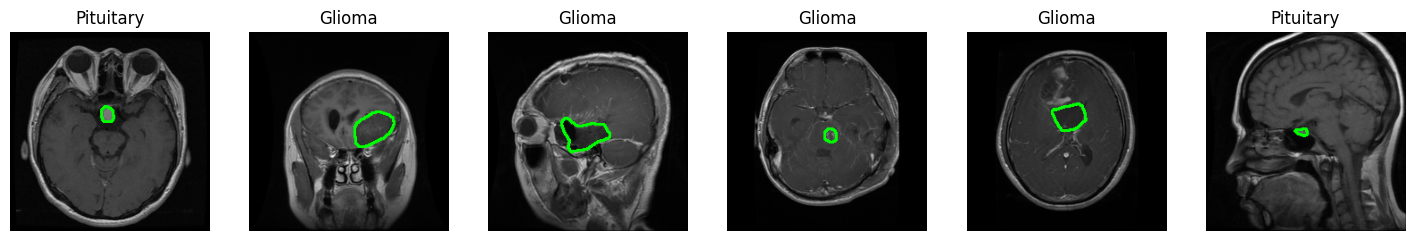

In [6]:
idx = pd.read_csv(os.path.join(FIGSHARE_PNG_DIR, "index.csv")).sample(6, random_state=0)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, (_, r) in zip(axes, idx.iterrows()):
    img = read_image_rgb(r["path"]).astype(np.uint8)
    m = resize_mask(cv2.imread(r["gt_ref"], cv2.IMREAD_GRAYSCALE) > 127)
    cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ax.imshow(cv2.drawContours(img.copy(), cnts, -1, (0, 255, 0), 2))
    ax.set_title(FIGSHARE_CLASSES[r["label"]])
    ax.axis("off")
plt.show()   # the green outline must sit exactly on the bright tumour

## Cell 4 — Build manifests, audit them, and compute Table 1 / Fig. 1 *from the data*
**What was wrong in v1:** Table 1 and the class-distribution figure were typed in by hand (`"Total Images": [1279, 7023, 15000, 400]`, chest `"No Finding": 6000, "Disease": 9000` — reversed relative to the real 8,753 / 6,246). That is the source of reviewer comments #1 and #10.
**Fix:** counts are computed from the manifests, with hard assertions (splits add up, no patient in two splits, every localisation image is in the test split).

Loading skin ...
Loading brain ...
Loading chest_xray ...
Loading histopathology ...
Loading brain_figshare ...
        Domain  Classes  Total  Train  Val  Test  Test_with_GT GT_type  Groups
          skin        2   1279    720  180   379           379   pixel    1279
         brain        4   7184   4481 1119  1584             0    none    7013
    chest_xray        2  14999   9372 2527  3100            84    bbox    3923
histopathology        4    399    255   64    80             0    none     399
brain_figshare        3   3064   1984  435   645           645   pixel     233

Exclusion / audit log (copy into the Datasets section):
  [skin]
           0  train: listed in CSV but image file missing
           0  train: no segmentation mask (kept for classification, excluded from localisation)
           0  test: listed in CSV but image file missing
           0  test: no segmentation mask (kept for classification, excluded from localisation)
  [brain]
        7200  files found
      

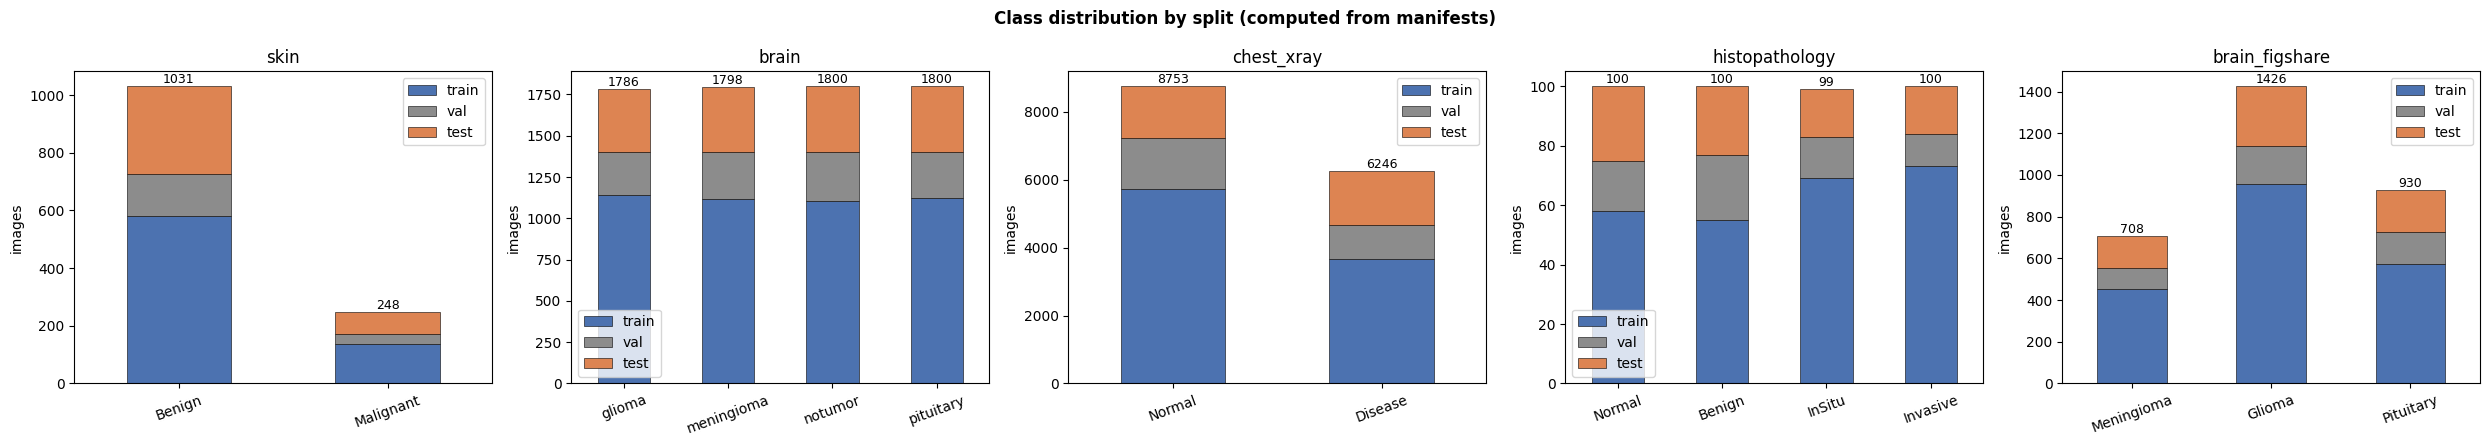

In [7]:
LOADERS = {"skin": load_skin, "brain": load_brain, "chest_xray": load_chest, "histopathology": load_histopathology}
if os.path.exists(os.path.join(FIGSHARE_PNG_DIR, "index.csv")):
    LOADERS["brain_figshare"] = load_brain_figshare
# (to create it once:  prepare_brain_figshare()  then re-run this cell)

def audit_manifest(D):
    m, name = D["manifest"], D["name"]
    assert set(m["split"]) <= {"train", "val", "test"}, f"{name}: unassigned rows"
    assert m["label"].notna().all(), f"{name}: missing labels"
    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = set(m.loc[m["split"] == a, "group"]) & set(m.loc[m["split"] == b, "group"])
        assert not overlap, f"{name}: {len(overlap)} groups (patients/duplicates) shared by {a} and {b}"
    gt_rows = m[m["gt_type"] != "none"]
    if name == "chest_xray":
        assert (gt_rows["split"] == "test").all(), "chest: a bbox image is in train/val (leakage)"
    counts = m["split"].value_counts()
    return dict(Domain=name, Classes=len(D["class_names"]), Total=len(m),
                Train=int(counts.get("train", 0)), Val=int(counts.get("val", 0)), Test=int(counts.get("test", 0)),
                Test_with_GT=int(((m["split"] == "test") & (m["gt_type"] != "none")).sum()),
                GT_type=",".join(sorted(set(m["gt_type"]) - {"none"})) or "none",
                Groups=int(m["group"].nunique()))

DATA, table1 = {}, []
for name, fn in LOADERS.items():
    print(f"Loading {name} ...")
    D = fn()
    DATA[name] = D
    row = audit_manifest(D)
    assert row["Train"] + row["Val"] + row["Test"] == row["Total"]
    table1.append(row)
    D["manifest"].to_csv(os.path.join(OUTPUT_DIR, f"manifest_{name}.csv"), index=False)

table1 = pd.DataFrame(table1)
table1.to_csv(os.path.join(OUTPUT_DIR, "table1_datasets.csv"), index=False)
print(table1.to_string(index=False))

print("\nExclusion / audit log (copy into the Datasets section):")
for name, items in EXCLUSIONS.items():
    print(f"  [{name}]")
    for reason, n in items:
        print(f"     {n:>7}  {reason}")
save_json(EXCLUSIONS, os.path.join(OUTPUT_DIR, "exclusion_log.json"))

# per-class x split counts (Table 1b) and Fig. 1, computed from the manifests
per_class = []
for name, D in DATA.items():
    m = D["manifest"]
    for k, c in enumerate(D["class_names"]):
        r = {"Domain": name, "Class": c}
        for s in ("train", "val", "test"):
            r[s] = int(((m["label"] == k) & (m["split"] == s)).sum())
        r["total"] = r["train"] + r["val"] + r["test"]
        per_class.append(r)
per_class = pd.DataFrame(per_class)
per_class.to_csv(os.path.join(OUTPUT_DIR, "table1b_class_counts.csv"), index=False)

fig, axes = plt.subplots(1, len(DATA), figsize=(5 * len(DATA), 4.5))
axes = np.atleast_1d(axes)
for ax, (name, D) in zip(axes, DATA.items()):
    sub = per_class[per_class["Domain"] == name].set_index("Class")[["train", "val", "test"]]
    sub.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#8C8C8C", "#DD8452"], edgecolor="black", lw=0.4)
    for i, tot in enumerate(sub.sum(axis=1)):
        ax.text(i, tot, str(int(tot)), ha="center", va="bottom", fontsize=9)
    ax.set_title(name); ax.set_xlabel(""); ax.set_ylabel("images"); ax.tick_params(axis="x", rotation=20)
plt.suptitle("Class distribution by split (computed from manifests)", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fig1_class_distribution.png"), dpi=200); plt.show()

## Cell 5 — Model: ResNet50 + head that exposes **logits**, and a fine-tuning step that actually works
**What was wrong in v1 (critical):** the ResNet was built with `input_tensor=`, which *flattens* its ~175 layers into your model (that is why `model.get_layer("conv5_block3_out")` worked in Grad-CAM). `unfreeze_model()` then searched for a nested `tf.keras.Model` whose name contains "resnet" — there is none — so **nothing was unfrozen**. Stage 2 was just 20 more epochs of head training at a 10× lower learning rate. The paper's "final 40 layers unfrozen" did not happen (and README says frozen-only, `Model.ipynb` uses a third head design — three different descriptions of one model).
Also: the Dense layer applied softmax directly, so Grad-CAM could only use probabilities (reviewer minor: logits vs post-softmax).
**Fix:** separate `logits` and `probs` layers; fine-tuning selects layers **by name** (the whole conv5 stage, BN frozen) and *asserts* that the number of trainable parameters increased. A sanity check shows what the /255 bug did to the backbone features.

In [8]:
HEAD_LAYERS = ("gap", "head_bn", "head_dropout", "logits", "probs")

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, **CFG["adam"]),
                  loss=tf.keras.losses.CategoricalCrossentropy(),
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

def build_model(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_0_255")
    x = tf.keras.applications.resnet50.preprocess_input(inputs)        # RGB 0..255 -> BGR, minus ImageNet mean
    backbone = tf.keras.applications.ResNet50(include_top=False, weights=None, input_tensor=x)
    backbone.load_weights(WEIGHTS)
    for layer in backbone.layers:
        layer.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(backbone.output)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Dropout(CFG["dropout"], name="head_dropout")(x)
    logits = tf.keras.layers.Dense(num_classes, dtype="float32", name="logits")(x)
    probs = tf.keras.layers.Activation("softmax", dtype="float32", name="probs")(logits)
    model = tf.keras.Model(inputs, probs, name=f"resnet50_{num_classes}cls")
    compile_model(model, CFG["lr_stage1"])
    return model

def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

def enable_finetuning(model):
    before = count_trainable(model)
    names = [l.name for l in model.layers]
    start = names.index(CFG["finetune_from_layer"])          # raises if the layer name is wrong
    for i, layer in enumerate(model.layers):
        if layer.name in HEAD_LAYERS:
            layer.trainable = True
        elif i >= start:
            layer.trainable = CFG["finetune_batchnorm"] or not isinstance(layer, tf.keras.layers.BatchNormalization)
        else:
            layer.trainable = False
    compile_model(model, CFG["lr_stage2"])
    after = count_trainable(model)
    assert after > before, "Fine-tuning did not unfreeze anything - v1 bug is back"
    n_layers = sum(1 for l in model.layers[start:] if l.trainable and l.weights and l.name not in HEAD_LAYERS)
    print(f"  Stage 2: trainable params {before:,} -> {after:,}  ({n_layers} backbone layers with weights unfrozen)")
    return before, after

def preprocessing_sanity_check(paths, n=32):
    """Compares backbone features for correctly scaled input (0..255) vs the v1 input (0..1)."""
    model = build_model(2)
    fe = tf.keras.Model(model.input, model.get_layer("gap").output)
    imgs = np.stack([read_image_rgb(p) for p in paths[:n]])
    f_ok, f_bug = fe.predict(imgs, verbose=0), fe.predict(imgs / 255.0, verbose=0)
    spread = lambda f: float(np.mean(np.std(f, axis=0)) / (np.mean(np.abs(f)) + 1e-8))
    print(f"  input range fed to model: correct [{imgs.min():.0f}, {imgs.max():.0f}]   v1 [0, 1]")
    print(f"  between-image feature spread (relative): correct = {spread(f_ok):.3f}   v1 bug = {spread(f_bug):.3f}")
    del model, fe; tf.keras.backend.clear_session()

rng_ = np.random.default_rng(0)
for name, D in DATA.items():
    tr_paths = D["manifest"].loc[D["manifest"]["split"] == "train", "path"].values
    print(f"[{name}]"); preprocessing_sanity_check(rng_.permutation(tr_paths))

[skin]
  input range fed to model: correct [0, 255]   v1 [0, 1]
  between-image feature spread (relative): correct = 1.087   v1 bug = 0.032
[brain]
  input range fed to model: correct [0, 255]   v1 [0, 1]
  between-image feature spread (relative): correct = 0.856   v1 bug = 0.181
[chest_xray]
  input range fed to model: correct [0, 255]   v1 [0, 1]
  between-image feature spread (relative): correct = 0.722   v1 bug = 0.045
[histopathology]
  input range fed to model: correct [6, 255]   v1 [0, 1]
  between-image feature spread (relative): correct = 1.071   v1 bug = 0.069
[brain_figshare]
  input range fed to model: correct [0, 250]   v1 [0, 1]
  between-image feature spread (relative): correct = 0.849   v1 bug = 0.106


## Cell 6 — Two-stage training with one explicit model-selection rule
**What was wrong in v1:** `ModelCheckpoint` saved `best_model.keras` by *val_accuracy*, but every later cell loaded `final_model.keras` (last epoch, or the best-val-loss epoch of Stage 2 only if early stopping fired). The paper describes the former. Class weights were tried with the majority class up-weighted (`{0: 2.5, 1: 1.0}` for chest) and in another cell computed from **test** labels (`y=te_labels`) — both wrong even though they were switched off.
**Fix:** one checkpoint across both stages, monitored on `val_loss`; that checkpoint is reloaded for all test evaluation; class weights from TRAIN labels, same rule for every domain; the stage transition is drawn from the real epoch count.

In [8]:
def domain_dir(domain, seed):
    d = os.path.join(OUTPUT_DIR, domain, f"seed_{seed}")
    os.makedirs(d, exist_ok=True)
    return d

def plot_training_curves(log, n1, domain, d):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key in zip(axes, ("accuracy", "loss")):
        ax.plot(log["epoch"] + 1, log[key], label="train")
        ax.plot(log["epoch"] + 1, log["val_" + key], "--", label="val")
        ax.axvline(n1 + 0.5, color="k", ls=":", lw=1, label="Stage 1 -> 2")
        ax.set_title(f"{domain} {key}"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(os.path.join(d, "training_curves.png"), dpi=150); plt.close()

def train_domain(D, seed):
    domain, man, K = D["name"], D["manifest"], len(D["class_names"])
    d = domain_dir(domain, seed)
    tf.keras.backend.clear_session(); set_seed(seed)
    tr, va = man[man["split"] == "train"], man[man["split"] == "val"]
    train_ds = make_dataset(tr["path"], tr["label"], K, training=True, seed=seed, augmenter=build_augmenter(seed))
    val_ds = make_dataset(va["path"], va["label"], K, training=False)
    class_weight = None
    if CFG["use_class_weights"]:
        w = compute_class_weight("balanced", classes=np.arange(K), y=tr["label"].values)
        class_weight = {int(k): float(v) for k, v in enumerate(w)}
    print(f"\n=== TRAIN {domain} | seed {seed} | train {len(tr)} val {len(va)} | class weights {class_weight}")

    model = build_model(K)
    best_path, log_path = os.path.join(d, "best.weights.h5"), os.path.join(d, "training_log.csv")
    if os.path.exists(log_path):
        os.remove(log_path)
    ckpt = tf.keras.callbacks.ModelCheckpoint(best_path, monitor=CFG["checkpoint_monitor"], mode="min",
                                              save_best_only=True, save_weights_only=True, verbose=0)
    logger = tf.keras.callbacks.CSVLogger(log_path, append=True)
    def stage_callbacks():
        return [ckpt, logger,
                tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=CFG["early_stop_patience"],
                                                 restore_best_weights=True, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=CFG["lr_plateau_factor"],
                                                     patience=CFG["lr_plateau_patience"], min_lr=CFG["min_lr"], verbose=1)]
    p1 = count_trainable(model)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=CFG["epochs_stage1"],
                   callbacks=stage_callbacks(), class_weight=class_weight, verbose=2)
    n1 = len(h1.epoch)
    _, p2 = enable_finetuning(model)
    h2 = model.fit(train_ds, validation_data=val_ds, initial_epoch=n1, epochs=n1 + CFG["epochs_stage2"],
                   callbacks=stage_callbacks(), class_weight=class_weight, verbose=2)
    model.load_weights(best_path)       # <- the ONLY model used for test evaluation and Grad-CAM
    log = pd.read_csv(log_path)
    best_row = log.loc[log[CFG["checkpoint_monitor"]].idxmin()]
    info = dict(domain=domain, seed=seed, n_train=len(tr), n_val=len(va), class_weight=class_weight,
                stage1_epochs_run=n1, stage2_epochs_run=len(h2.epoch),
                trainable_params_stage1=p1, trainable_params_stage2=p2,
                selected_epoch=int(best_row["epoch"]) + 1,
                selected_in_stage=1 if int(best_row["epoch"]) < n1 else 2,
                selected_val_loss=float(best_row["val_loss"]), selected_val_acc=float(best_row["val_accuracy"]))
    save_json(info, os.path.join(d, "train_info.json"))
    plot_training_curves(log, n1, domain, d)
    print(f"  selected checkpoint: epoch {info['selected_epoch']} (stage {info['selected_in_stage']}), "
          f"val_loss {info['selected_val_loss']:.4f}")
    return model, info

def load_trained_model(D, seed):
    model = build_model(len(D["class_names"]))
    model.load_weights(os.path.join(domain_dir(D["name"], seed), "best.weights.h5"))
    return model

## Cell 7 — Evaluation with baselines and confidence intervals
**What was wrong in v1:** accuracy was compared across tasks with different numbers of classes and imbalance (chance is 50 % for binary, 25 % for 4-class). Skin 80.7 % is essentially the benign proportion; chest 62.4 % is 4 points above always-"Normal". No majority baseline, no balanced accuracy, no CIs; AUC came from Keras' approximate thresholded metric; predictions were recomputed in three separate cells.
**Fix:** one `predictions_test.csv` per run (the single source of truth for correct/misclassified), sklearn metrics, majority and chance baselines, balanced accuracy, macro-F1, κ, AUC and stratified-bootstrap 95 % CIs, plus ECE (only needed if you talk about "confidence" — reviewer #12).

In [9]:
def predict_manifest(model, df, K):
    return model.predict(make_dataset(df["path"], df["label"], K, training=False), verbose=0)

def auc_fn(y, p):
    K = p.shape[1]
    if K == 2:
        return roc_auc_score(y, p[:, 1])
    return roc_auc_score(y, p, multi_class="ovr", average="macro", labels=list(range(K)))

def stratified_bootstrap_ci(fn, y, p, B, seed=0):
    rng = np.random.default_rng(seed)
    groups = [np.where(y == k)[0] for k in np.unique(y)]
    vals = []
    for _ in range(B):
        idx = np.concatenate([rng.choice(g, len(g), replace=True) for g in groups])
        try:
            vals.append(fn(y[idx], p[idx]))
        except ValueError:
            pass
    return [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]

def expected_calibration_error(y, p, n_bins=15):
    conf, pred = p.max(1), p.argmax(1)
    edges = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs((pred[m] == y[m]).mean() - conf[m].mean())
    return float(ece)

def classification_metrics(y, p, class_names):
    y, p = np.asarray(y, int), np.asarray(p, float)
    K = len(class_names); pred = p.argmax(1)
    cm = confusion_matrix(y, pred, labels=list(range(K)))
    rep = classification_report(y, pred, labels=list(range(K)), target_names=class_names,
                                output_dict=True, zero_division=0)
    B = CFG["n_bootstrap_cls"]
    out = dict(
        n_test=int(len(y)), class_counts=np.bincount(y, minlength=K).tolist(),
        majority_baseline_acc=float(np.bincount(y, minlength=K).max() / len(y)),
        chance_balanced_acc=1.0 / K,
        accuracy=float(accuracy_score(y, pred)),
        accuracy_ci=stratified_bootstrap_ci(lambda a, b: accuracy_score(a, b.argmax(1)), y, p, B),
        balanced_accuracy=float(balanced_accuracy_score(y, pred)),
        balanced_accuracy_ci=stratified_bootstrap_ci(lambda a, b: balanced_accuracy_score(a, b.argmax(1)), y, p, B),
        macro_f1=float(f1_score(y, pred, average="macro", zero_division=0)),
        cohen_kappa=float(cohen_kappa_score(y, pred)),
        auc=float(auc_fn(y, p)), auc_ci=stratified_bootstrap_ci(auc_fn, y, p, B),
        auc_definition="binary ROC-AUC" if K == 2 else "macro one-vs-rest ROC-AUC",
        per_class={c: dict(precision=rep[c]["precision"], recall=rep[c]["recall"], f1=rep[c]["f1-score"],
                           support=int(rep[c]["support"]),
                           auc_ovr=float(roc_auc_score((y == k).astype(int), p[:, k])) if 0 < (y == k).sum() < len(y) else None)
                   for k, c in enumerate(class_names)},
        confusion_matrix=cm.tolist(),
        confusion_matrix_row_pct=(cm / np.maximum(cm.sum(1, keepdims=True), 1) * 100).round(1).tolist(),
        ece=expected_calibration_error(y, p),
    )
    return out

def evaluate_domain(model, D, seed):
    d = domain_dir(D["name"], seed)
    man, K = D["manifest"], len(D["class_names"])
    te = man[man["split"] == "test"].reset_index(drop=True)
    p = predict_manifest(model, te, K)
    pred_df = pd.DataFrame({"path": te["path"], "image_id": te["image_id"], "label": te["label"],
                            "pred": p.argmax(1), "gt_type": te["gt_type"]})
    for k, c in enumerate(D["class_names"]):
        pred_df[f"prob_{c}"] = p[:, k]
    pred_df["correct"] = (pred_df["pred"] == pred_df["label"]).astype(int)
    pred_df.to_csv(os.path.join(d, "predictions_test.csv"), index=False)
    met = classification_metrics(te["label"].values, p, D["class_names"])
    save_json(met, os.path.join(d, "metrics.json"))
    print(f"  [{D['name']}] acc {met['accuracy']:.3f} (majority baseline {met['majority_baseline_acc']:.3f}) | "
          f"balanced acc {met['balanced_accuracy']:.3f} (chance {met['chance_balanced_acc']:.2f}) | "
          f"AUC {met['auc']:.3f} [{met['auc_ci'][0]:.3f}, {met['auc_ci'][1]:.3f}]")
    for c, v in met["per_class"].items():
        print(f"      {c:12s} recall {v['recall']:.3f}  precision {v['precision']:.3f}  n={v['support']}")
    return met

## Cell 8 — Grad-CAM with a **controlled target** and threshold-free localisation metrics
**What was wrong in v1 (critical for the paper's claim):** Grad-CAM targeted the *predicted class's softmax probability*. In chest X-ray every bbox image is *Disease*, so "correct" maps explain **Disease** and "misclassified" maps explain **Normal**. With a two-class softmax, ∂p(Normal)/∂z = −∂p(Disease)/∂z exactly, so the misclassified heatmaps are the ReLU of the *negated* disease-evidence map. A high IoU for misclassified cases therefore means "the lesion region contains evidence *against* Disease", which is close to the opposite of "the model localises the disease but cannot discriminate it". Softmax gradients also vanish when p≈1. Single τ = 0.5 only; all-zero maps silently counted as IoU 0.
**Fix (reviewer #3, #6, minor):**
* **Primary target** — the same score for every image: binary → positive-class logit margin (z_pos − z_neg); multiclass → true-class logit.
* **Secondary target** — predicted-class *logit* (your original design, kept for comparison), plus the v1 softmax target labelled `legacy` so you can show what changed.
* Metrics: IoU at τ ∈ {0.3…0.7}, **energy-in-GT** (share of heatmap mass inside the lesion; threshold-free), pointing game, all-zero-map flag.
* A **centre-prior baseline** (a fixed Gaussian blob, no model) — lesions are often central, so any metric must beat this.
* Correct/misclassified status is read from `predictions_test.csv`, and the Grad-CAM forward pass is checked against it.

In [10]:
def centre_prior(size=IMG_SIZE, sigma_frac=0.25):
    yy, xx = np.mgrid[0:size, 0:size]; c = (size - 1) / 2.0; s = sigma_frac * size
    g = np.exp(-((xx - c) ** 2 + (yy - c) ** 2) / (2 * s * s))
    return (g / g.max()).astype(np.float32)
CENTRE_PRIOR = centre_prior()

def make_cam_model(model):
    return tf.keras.Model(model.input, [model.get_layer(CFG["gradcam_layer"]).output,
                                        model.get_layer("logits").output])

def primary_target_name(D):
    return "fixed_positive_margin" if len(D["class_names"]) == 2 else "fixed_true_class"

def gradcam_all_targets(cam_model, img_0_255, D, true_label):
    """Grad-CAM (Selvaraju et al.) for several targets from ONE forward pass. Returns {target: (cam, all_zero)}."""
    x = tf.convert_to_tensor(img_0_255[None], tf.float32)
    K = len(D["class_names"])
    with tf.GradientTape(persistent=True) as tape:
        conv, logits = cam_model(x, training=False)
        pred = tf.argmax(logits[0])
        targets = {}
        if K == 2:
            pos = D["positive_class"]; neg = 1 - pos
            targets["fixed_positive_margin"] = logits[0, pos] - logits[0, neg]   # PRIMARY
        else:
            targets["fixed_true_class"] = logits[0, int(true_label)]             # PRIMARY
        targets["predicted_logit"] = tf.gather(logits[0], pred)                  # SECONDARY
        targets["predicted_prob_legacy"] = tf.gather(tf.nn.softmax(logits)[0], pred)   # = v1 target
    conv_np = conv[0].numpy().astype(np.float32)
    maps = {}
    for tname, score in targets.items():
        g = tape.gradient(score, conv)
        alpha = tf.reduce_mean(g, axis=(1, 2))[0].numpy()            # Eq. (1): GAP of gradients
        cam = np.maximum(conv_np @ alpha, 0.0)                        # Eq. (2): ReLU(sum_k alpha_k A^k)
        peak = float(cam.max()); all_zero = peak <= 1e-12
        cam = cam / peak if not all_zero else cam
        maps[tname] = (cv2.resize(cam.astype(np.float32), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR),
                       bool(all_zero))
    del tape
    return maps, logits[0].numpy()

def localisation_metrics(cam, gt, taus):
    gt = np.asarray(gt).astype(bool); res = {}
    for tau in taus:
        a = cam >= tau
        union = np.logical_or(a, gt).sum()
        res[f"iou@{tau}"] = float(np.logical_and(a, gt).sum() / union) if union > 0 else np.nan
    total = float(cam.sum())
    res["energy_in_gt"] = float(cam[gt].sum() / total) if total > 0 else np.nan
    if cam.max() > 0:
        r, c = np.unravel_index(int(np.argmax(cam)), cam.shape); res["pointing_hit"] = float(gt[r, c])
    else:
        res["pointing_hit"] = np.nan
    res["gt_area_frac"] = float(gt.mean())
    # shortcut check: attention on the image border (markers, text, dermoscope vignette), lesion excluded
    b = max(1, int(round(0.10 * cam.shape[0])))
    border = np.zeros_like(gt); border[:b, :] = border[-b:, :] = border[:, :b] = border[:, -b:] = True
    border &= ~gt
    res["energy_border"] = float(cam[border].sum() / total) if total > 0 else np.nan
    res["border_area_frac"] = float(border.mean())      # = energy_border of a uniform (uninformative) map
    return res
    
def run_localisation(model, D, seed):
    d = domain_dir(D["name"], seed)
    man = D["manifest"]
    test = man[(man["split"] == "test") & (man["gt_type"] != "none")]
    if len(test) == 0:
        return None
    preds = pd.read_csv(os.path.join(d, "predictions_test.csv")).set_index("path")
    cam_model = make_cam_model(model)
    rows, mismatch = [], 0
    for i, (_, r) in enumerate(test.iterrows()):
        gt = load_gt_mask(r)
        maps, logits = gradcam_all_targets(cam_model, read_image_rgb(r["path"]), D, r["label"])
        pred_saved = int(preds.loc[r["path"], "pred"])
        mismatch += int(int(np.argmax(logits)) != pred_saved)
        base = dict(path=r["path"], label=int(r["label"]), pred=pred_saved, correct=int(pred_saved == int(r["label"])))
        if len(D["class_names"]) == 2:
            base["logit_margin_pos"] = float(logits[D["positive_class"]] - logits[1 - D["positive_class"]])
        for tname, (cam, zero) in maps.items():
            rows.append({**base, "target": tname, "cam_all_zero": zero,
                         **localisation_metrics(cam, gt, CFG["cam_thresholds"])})
        rows.append({**base, "target": "centre_prior_baseline", "cam_all_zero": False,
                     **localisation_metrics(CENTRE_PRIOR, gt, CFG["cam_thresholds"])})
        if i % 50 == 0:
            print(f"    Grad-CAM {i}/{len(test)}")
    loc = pd.DataFrame(rows)
    loc.to_csv(os.path.join(d, "localisation_per_sample.csv"), index=False)
    print(f"  [{D['name']}] localisation on {len(test)} held-out test images; "
          f"prediction mismatches vs predictions_test.csv: {mismatch} (should be 0)")
    return loc

## Cell 9 — Statistics for correct vs misclassified (reviewer #4, #5, #6, #13)
For each target × metric × subset we report: n, mean and median per group with bootstrap 95 % CIs, Δ = M − C (mean and median) with bootstrap CIs, a two-sided Mann–Whitney U test, a permutation test on Δmean, and Cliff's δ as the effect size. The ratio of means is kept only as a secondary descriptor (it explodes when the denominator is ≈0 — the 24.4× problem, reviewer #5).

**Class-conditioned subsets** remove the class-composition confound (reviewer #13): within *Malignant* (TP vs FN) and *Benign* (TN vs FP) for skin; within *Disease* (TP vs FN) for chest.

**Pre-declared primary endpoint:** Δ energy-in-GT, primary (fixed) target, within the positive class. Holm correction is applied across the metrics of that family. Decide this *before* looking at the numbers and say so in the paper.

In [11]:
def cliffs_delta(a, b):
    """P(a > b) - P(a < b), computed from the Mann-Whitney U of a vs b."""
    u = sps.mannwhitneyu(a, b, alternative="two-sided").statistic
    return float(2.0 * u / (len(a) * len(b)) - 1.0)

def cliffs_label(d):     # thresholds of Romano et al. (2006) - verify before citing
    a = abs(d)
    return "negligible" if a < 0.147 else "small" if a < 0.33 else "medium" if a < 0.474 else "large"

def boot_stat(a, fn, B, rng):
    return fn(a[rng.integers(0, len(a), (B, len(a)))], axis=1)

def perm_test_mean(a, b, B, rng):
    pooled = np.concatenate([a, b]); na = len(a); obs = a.mean() - b.mean()
    diffs = np.empty(B); chunk = 1000
    for s in range(0, B, chunk):
        n = min(chunk, B - s)
        perm = rng.permuted(np.tile(pooled, (n, 1)), axis=1)
        diffs[s:s + n] = perm[:, :na].mean(1) - perm[:, na:].mean(1)
    return float((np.sum(np.abs(diffs) >= abs(obs)) + 1) / (B + 1))

def compare_groups(M, C, seed=0):
    M, C = np.asarray(M, float), np.asarray(C, float)
    out = dict(n_C=len(C), n_M=len(M))
    if len(M) < 3 or len(C) < 3:
        out["note"] = "insufficient n (<3) in a group - not tested"
        return out
    rng = np.random.default_rng(seed); B = CFG["n_bootstrap"]
    for lab, arr in (("C", C), ("M", M)):
        bm, bmed = boot_stat(arr, np.mean, B, rng), boot_stat(arr, np.median, B, rng)
        out[f"mean_{lab}"], out[f"mean_{lab}_ci"] = float(arr.mean()), np.percentile(bm, [2.5, 97.5]).tolist()
        out[f"median_{lab}"], out[f"median_{lab}_ci"] = float(np.median(arr)), np.percentile(bmed, [2.5, 97.5]).tolist()
    dm = boot_stat(M, np.mean, B, rng) - boot_stat(C, np.mean, B, rng)
    dmed = boot_stat(M, np.median, B, rng) - boot_stat(C, np.median, B, rng)
    out["delta_mean"], out["delta_mean_ci"] = float(M.mean() - C.mean()), np.percentile(dm, [2.5, 97.5]).tolist()
    out["delta_median"], out["delta_median_ci"] = float(np.median(M) - np.median(C)), np.percentile(dmed, [2.5, 97.5]).tolist()
    out["ratio_of_means"] = float(M.mean() / C.mean()) if C.mean() > 1e-6 else None
    if np.unique(np.concatenate([M, C])).size > 1:
        out["mwu_p"] = float(sps.mannwhitneyu(M, C, alternative="two-sided").pvalue)
        out["cliffs_delta_M_vs_C"] = cliffs_delta(M, C)
        out["cliffs_magnitude"] = cliffs_label(out["cliffs_delta_M_vs_C"])
    out["perm_p_delta_mean"] = perm_test_mean(M, C, CFG["n_permutations"], rng)
    return out

def holm(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p)
    adj = np.empty(m); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

def run_statistics(loc, D, seed):
    d = domain_dir(D["name"], seed)
    metrics = [f"iou@{t}" for t in CFG["cam_thresholds"]] + ["energy_in_gt", "pointing_hit"]
    subsets = [("all_classes", loc)]
    for k, c in enumerate(D["class_names"]):
        sub = loc[loc["label"] == k]
        if len(sub):
            subsets.append((f"true={c}", sub))
    rows = []
    for target in loc["target"].unique():
        for sname, sub in subsets:
            st = sub[sub["target"] == target]
            for metric in metrics:
                for zero_policy in ("include_zero_maps", "exclude_zero_maps"):
                    x = st if zero_policy == "include_zero_maps" else st[~st["cam_all_zero"]]
                    x = x[[metric, "correct"]].dropna()
                    res = compare_groups(x.loc[x["correct"] == 0, metric].values,
                                         x.loc[x["correct"] == 1, metric].values, seed=seed)
                    rows.append(dict(domain=D["name"], seed=seed, target=target, subset=sname,
                                     metric=metric, zero_maps=zero_policy,
                                     n_zero_maps=int(st["cam_all_zero"].sum()), **res))
    stats_df = pd.DataFrame(rows)
    # primary family
    prim_target = primary_target_name(D)
    prim_subset = (f"true={D['class_names'][D['positive_class']]}" if D.get("positive_class") is not None
                   else "all_classes")
    fam = ((stats_df["target"] == prim_target) & (stats_df["subset"] == prim_subset)
           & (stats_df["zero_maps"] == "include_zero_maps") & stats_df.get("mwu_p", pd.Series(np.nan, index=stats_df.index)).notna())
    stats_df["holm_p_primary_family"] = np.nan
    if fam.any():
        stats_df.loc[fam, "holm_p_primary_family"] = holm(stats_df.loc[fam, "mwu_p"].values)
    stats_df["is_primary_endpoint"] = fam & (stats_df["metric"] == CFG["primary_metric"])
    stats_df.to_csv(os.path.join(d, "localisation_stats.csv"), index=False)
    prim = stats_df[stats_df["is_primary_endpoint"]]
    if len(prim):
        r = prim.iloc[0]
        print(f"  PRIMARY [{D['name']}] {prim_subset}: {CFG['primary_metric']} "
              f"C={r.get('mean_C', np.nan):.3f} (n={r['n_C']}) vs M={r.get('mean_M', np.nan):.3f} (n={r['n_M']}); "
              f"delta={r.get('delta_mean', np.nan):+.3f} CI {r.get('delta_mean_ci')}; "
              f"MWU p={r.get('mwu_p', np.nan):.4f}; Cliff's d={r.get('cliffs_delta_M_vs_C', np.nan):+.2f}")
    else:
        print(f"  PRIMARY [{D['name']}]: not testable (see 'note' column: probably n<3 in a group)")
    return stats_df

## Cell 10 — Run everything from ONE driver
**What was wrong in v1:** each domain was trained in a different cell, cells were re-run out of order (execution counts 8 → 21 → 10 → 22 → 14…), and later cells read whatever `metrics.json` happened to be on disk. Result: histopathology accuracy is 0.3625 in one cell and 0.3375 in the headline figure; the Grad-CAM cell ran only chest while the skin numbers came from an earlier session.
**Fix:** one loop; every artefact goes to `outputs/v2_corrected/<domain>/seed_<s>/`. Set `FORCE_RETRAIN = False` to re-use finished runs without retraining.

In [33]:
FORCE_RETRAIN = False
RUN_DOMAINS = list(DATA.keys())          # e.g. ["chest_xray"] while debugging

for domain in RUN_DOMAINS:
    D = DATA[domain]
    for seed in SEEDS:
        d = domain_dir(domain, seed)
        done = os.path.exists(os.path.join(d, "best.weights.h5")) and os.path.exists(os.path.join(d, "train_info.json"))
        if FORCE_RETRAIN or not done:
            model, info = train_domain(D, seed)
        else:
            tf.keras.backend.clear_session(); model = load_trained_model(D, seed)
            print(f"\n=== {domain} seed {seed}: re-using saved checkpoint")
        evaluate_domain(model, D, seed)
        loc = run_localisation(model, D, seed)
        if loc is not None:
            run_statistics(loc, D, seed)
        else:
            print(f"  [{domain}] no localisation ground truth -> localisation NOT EVALUATED (not zero)")
        del model
        tf.keras.backend.clear_session()
print("\nALL RUNS COMPLETE")


=== skin seed 42: re-using saved checkpoint
  [skin] acc 0.739 (majority baseline 0.802) | balanced acc 0.671 (chance 0.50) | AUC 0.740 [0.680, 0.799]
      Benign       recall 0.783  precision 0.878  n=304
      Malignant    recall 0.560  precision 0.389  n=75
    Grad-CAM 0/379
    Grad-CAM 50/379
    Grad-CAM 100/379
    Grad-CAM 150/379
    Grad-CAM 200/379
    Grad-CAM 250/379
    Grad-CAM 300/379
    Grad-CAM 350/379
  [skin] localisation on 379 held-out test images; prediction mismatches vs predictions_test.csv: 0 (should be 0)
  PRIMARY [skin] true=Malignant: energy_in_gt C=0.605 (n=42) vs M=0.371 (n=33); delta=-0.235 CI [-0.3514263246542333, -0.11188637990421349]; MWU p=0.0003; Cliff's d=-0.49

=== TRAIN skin | seed 43 | train 720 val 180 | class weights {0: 0.6185567010309279, 1: 2.608695652173913}
Epoch 1/10
45/45 - 21s - loss: 0.9686 - accuracy: 0.5361 - auc: 0.5638 - val_loss: 0.4832 - val_accuracy: 0.7778 - val_auc: 0.8520 - lr: 1.0000e-04 - 21s/epoch - 459ms/step
Epoch 

## Cell 11a — Seed consistency + pooled primary endpoint
**Reads:** `localisation_stats.csv`, `localisation_per_sample.csv` for every seed (files written by Cell 10)
**Writes:** `table5_seed_consistency.csv`, `pooled_primary_endpoint.json`
**Used in paper:** Table 5 (per-seed rows and "pooled" rows)
**Training needed:** no. Safe to re-run at any time.

In [ ]:
rows, pooled = [], {}
for dname, D in DATA.items():
    per_seed = []
    for s in SEEDS:
        fs = os.path.join(domain_dir(dname, s), "localisation_stats.csv")
        fl = os.path.join(domain_dir(dname, s), "localisation_per_sample.csv")
        if not os.path.exists(fs): continue
        st = pd.read_csv(fs); r = st[st["is_primary_endpoint"] == True]
        if len(r):
            r = r.iloc[0]
            rows.append(dict(domain=dname, seed=s, n_C=r["n_C"], n_M=r["n_M"], mean_C=r.get("mean_C"),
                             mean_M=r.get("mean_M"), delta=r.get("delta_mean"), delta_ci=r.get("delta_mean_ci"),
                             p=r.get("mwu_p"), cliffs=r.get("cliffs_delta_M_vs_C")))
        loc = pd.read_csv(fl); loc["seed"] = s; per_seed.append(loc)
    if not per_seed: continue
    L = pd.concat(per_seed, ignore_index=True)
    pos = D.get("positive_class")
    L = L[L["target"] == primary_target_name(D)]
    if pos is not None: L = L[L["label"] == pos]
    L = L.dropna(subset=[CFG["primary_metric"]])
    paths = L["path"].unique(); by_path = {p: g for p, g in L.groupby("path")}
    rng = np.random.default_rng(0); deltas = []
    for _ in range(5000):                                   # cluster bootstrap over IMAGES
        S = pd.concat([by_path[p] for p in rng.choice(paths, len(paths), replace=True)])
        M, C = S.loc[S["correct"] == 0, CFG["primary_metric"]], S.loc[S["correct"] == 1, CFG["primary_metric"]]
        if len(M) and len(C): deltas.append(M.mean() - C.mean())
    M, C = L.loc[L["correct"] == 0, CFG["primary_metric"]], L.loc[L["correct"] == 1, CFG["primary_metric"]]
    pooled[dname] = dict(delta=float(M.mean() - C.mean()), ci=np.percentile(deltas, [2.5, 97.5]).round(3).tolist(),
                         n_images=len(paths), n_seeds=L["seed"].nunique())

seed_df = pd.DataFrame(rows)
seed_df.to_csv(os.path.join(OUTPUT_DIR, "table5_seed_consistency.csv"), index=False)
print(seed_df.to_string(index=False))
print("\nPooled across seeds (image-level cluster bootstrap):")
for d, v in pooled.items():
    print(f"  {d:15s} delta={v['delta']:+.3f}  95% CI {v['ci']}  ({v['n_images']} images x {v['n_seeds']} seeds)")
save_json(pooled, os.path.join(OUTPUT_DIR, "pooled_primary_endpoint.json"))

## Cell 11b — Border attention, classes mixed (SUPERSEDED, kept for the record)
**Reads:** `localisation_per_sample.csv` (from Cell 10)
**Writes:** `table6_border_attention.csv`
**Not used in paper.** Mixing true classes reverses the skin result; the paper uses the
class-split version from Cell 14 (Fix 2), see paper §5.4.

In [ ]:
rows = []
for dname, D in DATA.items():
    for s in SEEDS:
        f = os.path.join(domain_dir(dname, s), "localisation_per_sample.csv")
        if not os.path.exists(f): continue
        L = pd.read_csv(f)
        if "energy_border" not in L: continue
        L = L[L["target"] == primary_target_name(D)].dropna(subset=["energy_border"])
        res = compare_groups(L.loc[L["correct"] == 0, "energy_border"].values,
                             L.loc[L["correct"] == 1, "energy_border"].values, seed=s)
        rows.append(dict(domain=dname, seed=s, uniform_level=round(L["border_area_frac"].mean(), 3),
                         mean_all=round(L["energy_border"].mean(), 3),
                         share_images_above_uniform=round((L["energy_border"] > L["border_area_frac"]).mean(), 3),
                         mean_C=res.get("mean_C"), mean_M=res.get("mean_M"),
                         delta=res.get("delta_mean"), delta_ci=res.get("delta_mean_ci"), p=res.get("mwu_p")))
border_df = pd.DataFrame(rows)
border_df.to_csv(os.path.join(OUTPUT_DIR, "table6_border_attention.csv"), index=False)
print(border_df.to_string(index=False))

## Cell 11 — Aggregate results and export the numbers the paper is allowed to use
Every number in the manuscript should be copied from `paper_numbers.json`, `table3_classification.csv` and `table4_localisation_primary.csv`. `caption_facts.txt` writes the confusion-matrix sentences for you, so a caption can never again say "malignant 94.7 %" when 94.7 % of malignant images were predicted *benign* (reviewer #2).

In [12]:
def seed_dirs(domain):
    return sorted(glob.glob(os.path.join(OUTPUT_DIR, domain, "seed_*")))

def mean_sd(vals):
    vals = [v for v in vals if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if not vals: return None
    return dict(mean=float(np.mean(vals)), sd=float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0, n_seeds=len(vals))

PAPER, t3_rows, t4_rows, captions = {}, [], [], []
for domain, D in DATA.items():
    runs = [json.load(open(os.path.join(s, "metrics.json"))) for s in seed_dirs(domain)
            if os.path.exists(os.path.join(s, "metrics.json"))]
    if not runs:
        continue
    first = runs[0]
    entry = dict(n_test=first["n_test"], class_counts_test=first["class_counts"],
                 majority_baseline_acc=first["majority_baseline_acc"], chance_balanced_acc=first["chance_balanced_acc"])
    for key in ("accuracy", "balanced_accuracy", "macro_f1", "cohen_kappa", "auc", "ece"):
        entry[key] = mean_sd([r[key] for r in runs])
    entry["ci_first_seed"] = {k: first[k + "_ci"] for k in ("accuracy", "balanced_accuracy", "auc")}
    entry["per_class_recall"] = {c: mean_sd([r["per_class"][c]["recall"] for r in runs]) for c in D["class_names"]}
    PAPER[domain] = dict(classification=entry)
    row = dict(Domain=domain, n_test=first["n_test"], Majority_baseline=round(first["majority_baseline_acc"], 3),
               Accuracy=f"{entry['accuracy']['mean']:.3f} ± {entry['accuracy']['sd']:.3f}",
               Balanced_acc=f"{entry['balanced_accuracy']['mean']:.3f} ± {entry['balanced_accuracy']['sd']:.3f}",
               Macro_F1=f"{entry['macro_f1']['mean']:.3f}", Kappa=f"{entry['cohen_kappa']['mean']:.3f}",
               AUC=f"{entry['auc']['mean']:.3f} ± {entry['auc']['sd']:.3f}")
    for c in D["class_names"]:
        row[f"Recall_{c}"] = f"{entry['per_class_recall'][c]['mean']:.3f}"
    t3_rows.append(row)
    cm_pct = np.array(first["confusion_matrix_row_pct"])
    for i, ci in enumerate(D["class_names"]):
        worst = int(np.argmax(np.where(np.arange(len(D["class_names"])) == i, -1, cm_pct[i])))
        err = (f"; the most common error was {D['class_names'][worst]} ({cm_pct[i, worst]:.1f}%)."
               if cm_pct[i, worst] > 0 else "; no errors.")
        captions.append(f"{domain}: {cm_pct[i, i]:.1f}% of true {ci} images were classified correctly" + err)
    # localisation (primary endpoint rows, every seed)
    st_files = [os.path.join(s, "localisation_stats.csv") for s in seed_dirs(domain)]
    st_files = [f for f in st_files if os.path.exists(f)]
    if st_files:
        st = pd.concat([pd.read_csv(f) for f in st_files], ignore_index=True)
        prim = st[st["is_primary_endpoint"] == True]
        PAPER[domain]["localisation_primary"] = prim.to_dict(orient="records")
        t4_rows.append(prim)
    else:
        PAPER[domain]["localisation_primary"] = "NOT EVALUATED - no localisation ground truth"

t3 = pd.DataFrame(t3_rows); t3.to_csv(os.path.join(OUTPUT_DIR, "table3_classification.csv"), index=False)
print(t3.to_string(index=False))
if t4_rows:
    t4 = pd.concat(t4_rows, ignore_index=True)
    t4.to_csv(os.path.join(OUTPUT_DIR, "table4_localisation_primary.csv"), index=False)
    cols = [c for c in ("domain", "seed", "subset", "metric", "n_C", "mean_C", "n_M", "mean_M", "delta_mean",
                        "delta_mean_ci", "mwu_p", "holm_p_primary_family", "cliffs_delta_M_vs_C", "cliffs_magnitude")
            if c in t4.columns]
    print("\nPRIMARY localisation endpoint:\n", t4[cols].to_string(index=False))
save_json(PAPER, os.path.join(OUTPUT_DIR, "paper_numbers.json"))
with open(os.path.join(OUTPUT_DIR, "caption_facts.txt"), "w") as f:
    f.write("\n".join(captions))
print("\n".join(captions))

        Domain  n_test  Majority_baseline      Accuracy  Balanced_acc Macro_F1 Kappa           AUC Recall_Benign Recall_Malignant Recall_glioma Recall_meningioma Recall_notumor Recall_pituitary Recall_Normal Recall_Disease Recall_InSitu Recall_Invasive Recall_Meningioma Recall_Glioma Recall_Pituitary
          skin     379              0.802 0.760 ± 0.018 0.619 ± 0.046    0.615 0.234 0.698 ± 0.039         0.852            0.387           NaN               NaN            NaN              NaN           NaN            NaN           NaN             NaN               NaN           NaN              NaN
         brain    1584              0.253 0.940 ± 0.007 0.939 ± 0.007    0.938 0.920 0.987 ± 0.002           NaN              NaN         0.800             0.956          0.999            0.999           NaN            NaN           NaN             NaN               NaN           NaN              NaN
    chest_xray    3100              0.511 0.637 ± 0.007 0.636 ± 0.007    0.636 0.272 0.680 ± 0

## Cell 12 — Figures (all drawn from saved CSV/JSON; missing ≠ zero)
**What was wrong in v1:** Brain MRI and histopathology were drawn as IoU bars of height 0 (reviewer #7); the figure title asserted "ordered by visual distance from ImageNet" as if it were a measured variable (reviewer #11); Grad-CAM examples were the *first* 3 correct / 3 wrong images, not a random sample, and showed no ground truth; the IoU histograms were recomputed in a separate cell with a separate prediction pass.

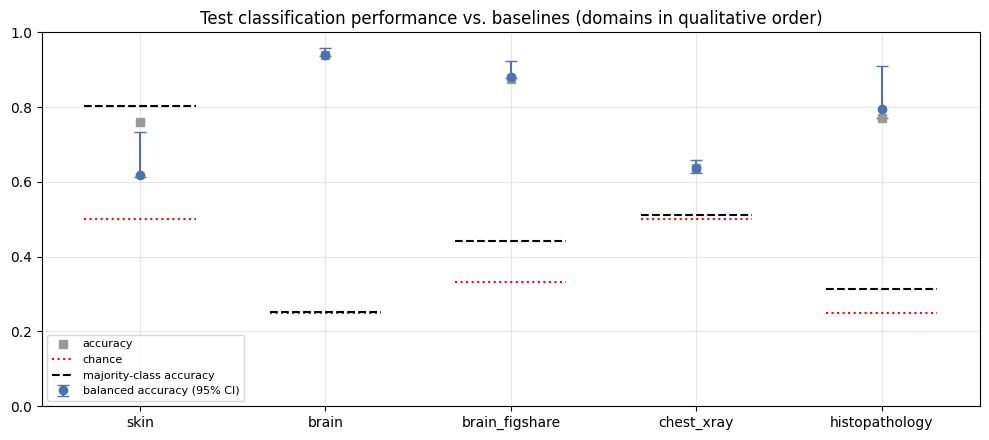

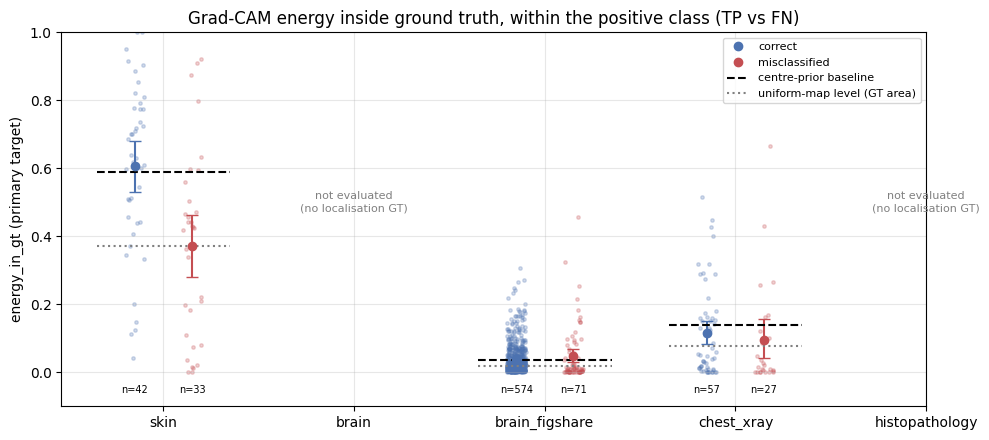

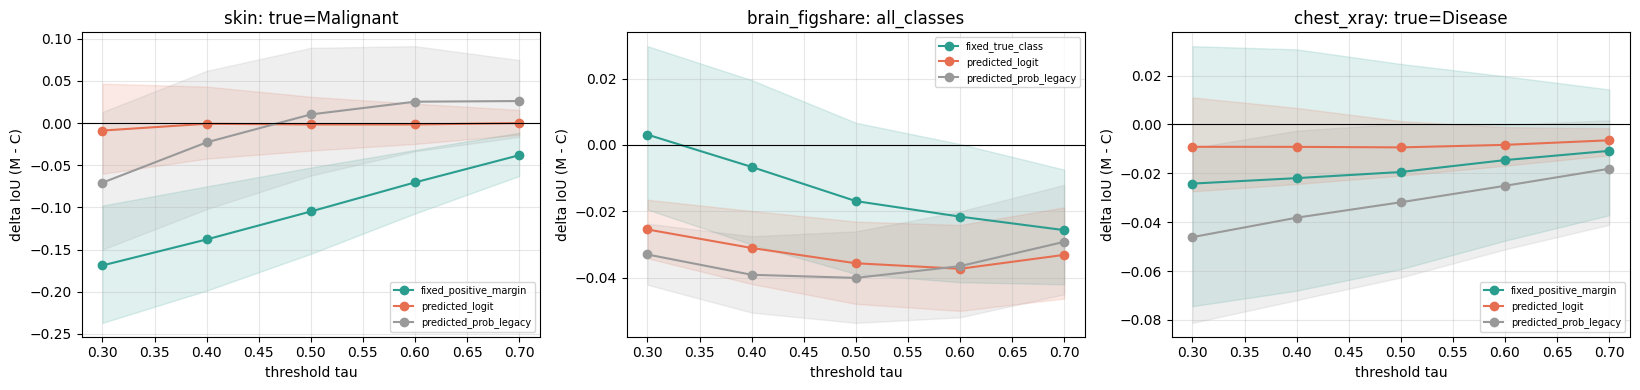

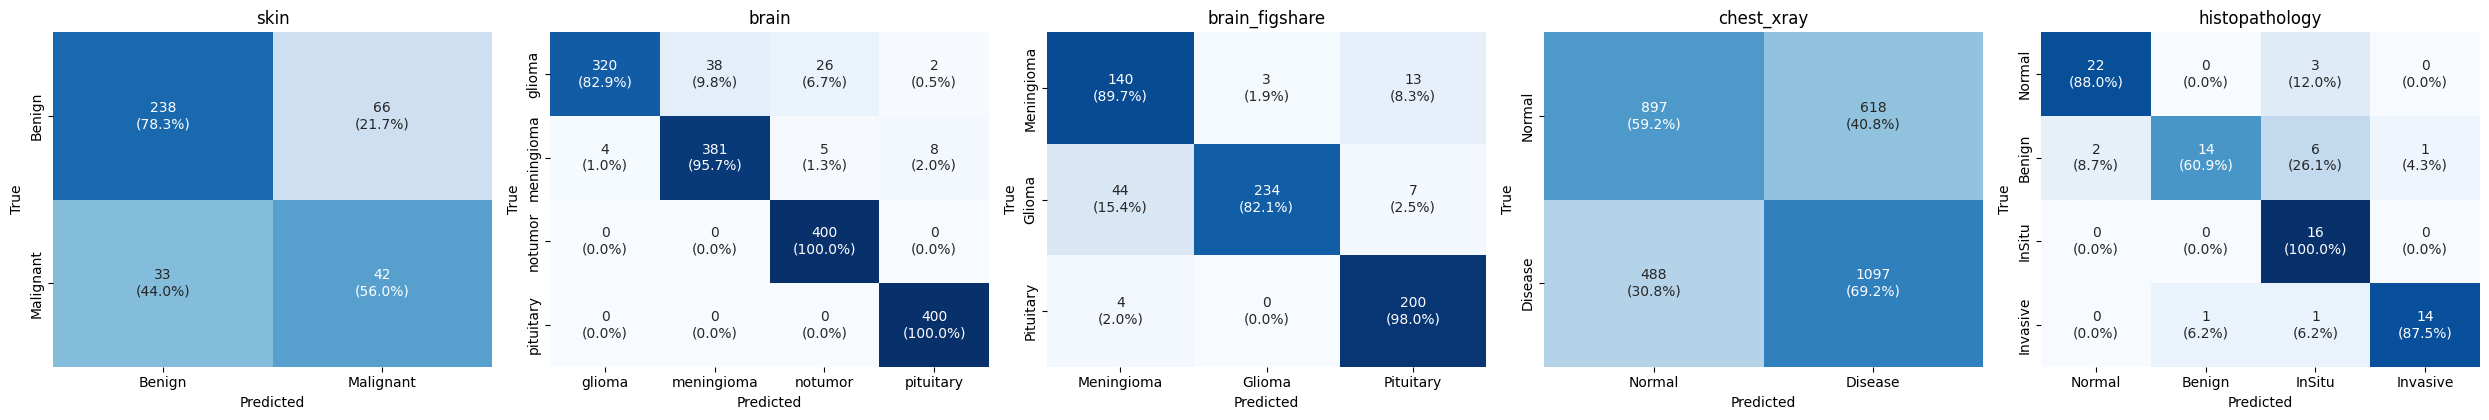

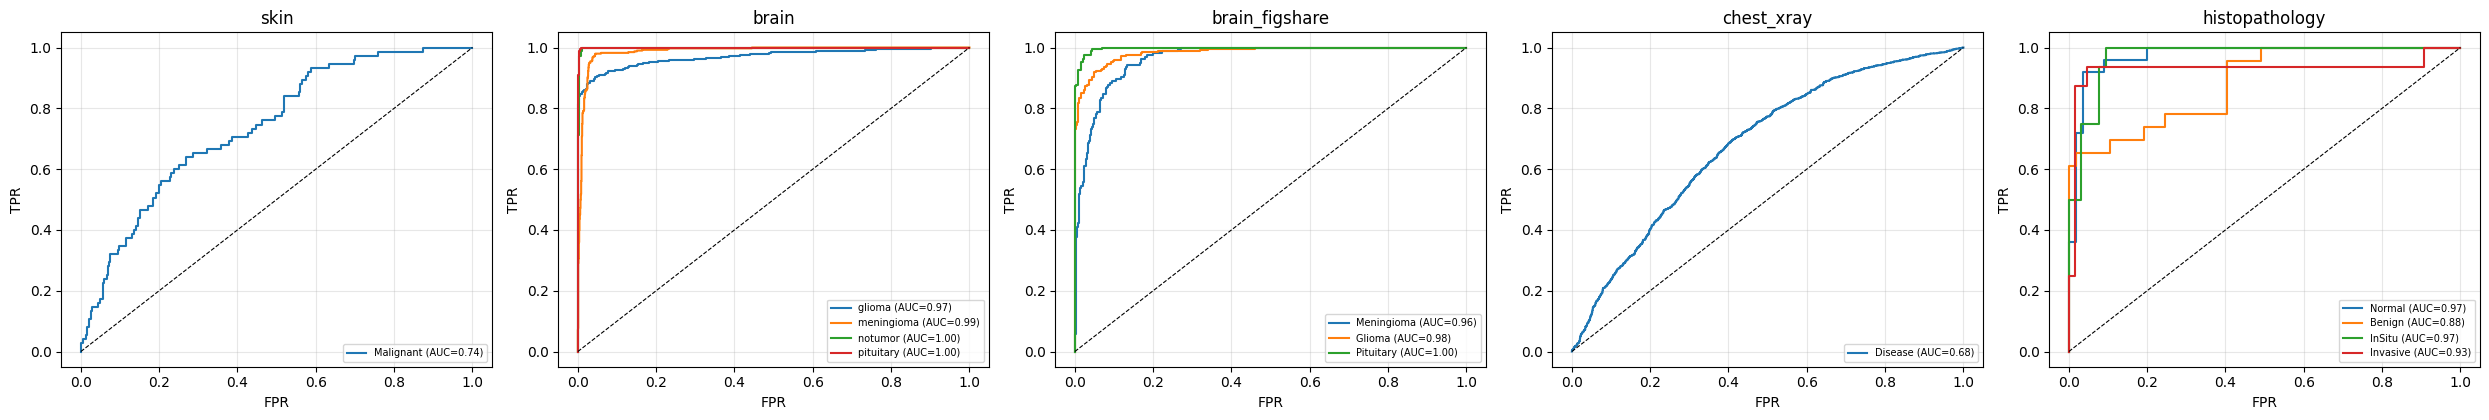

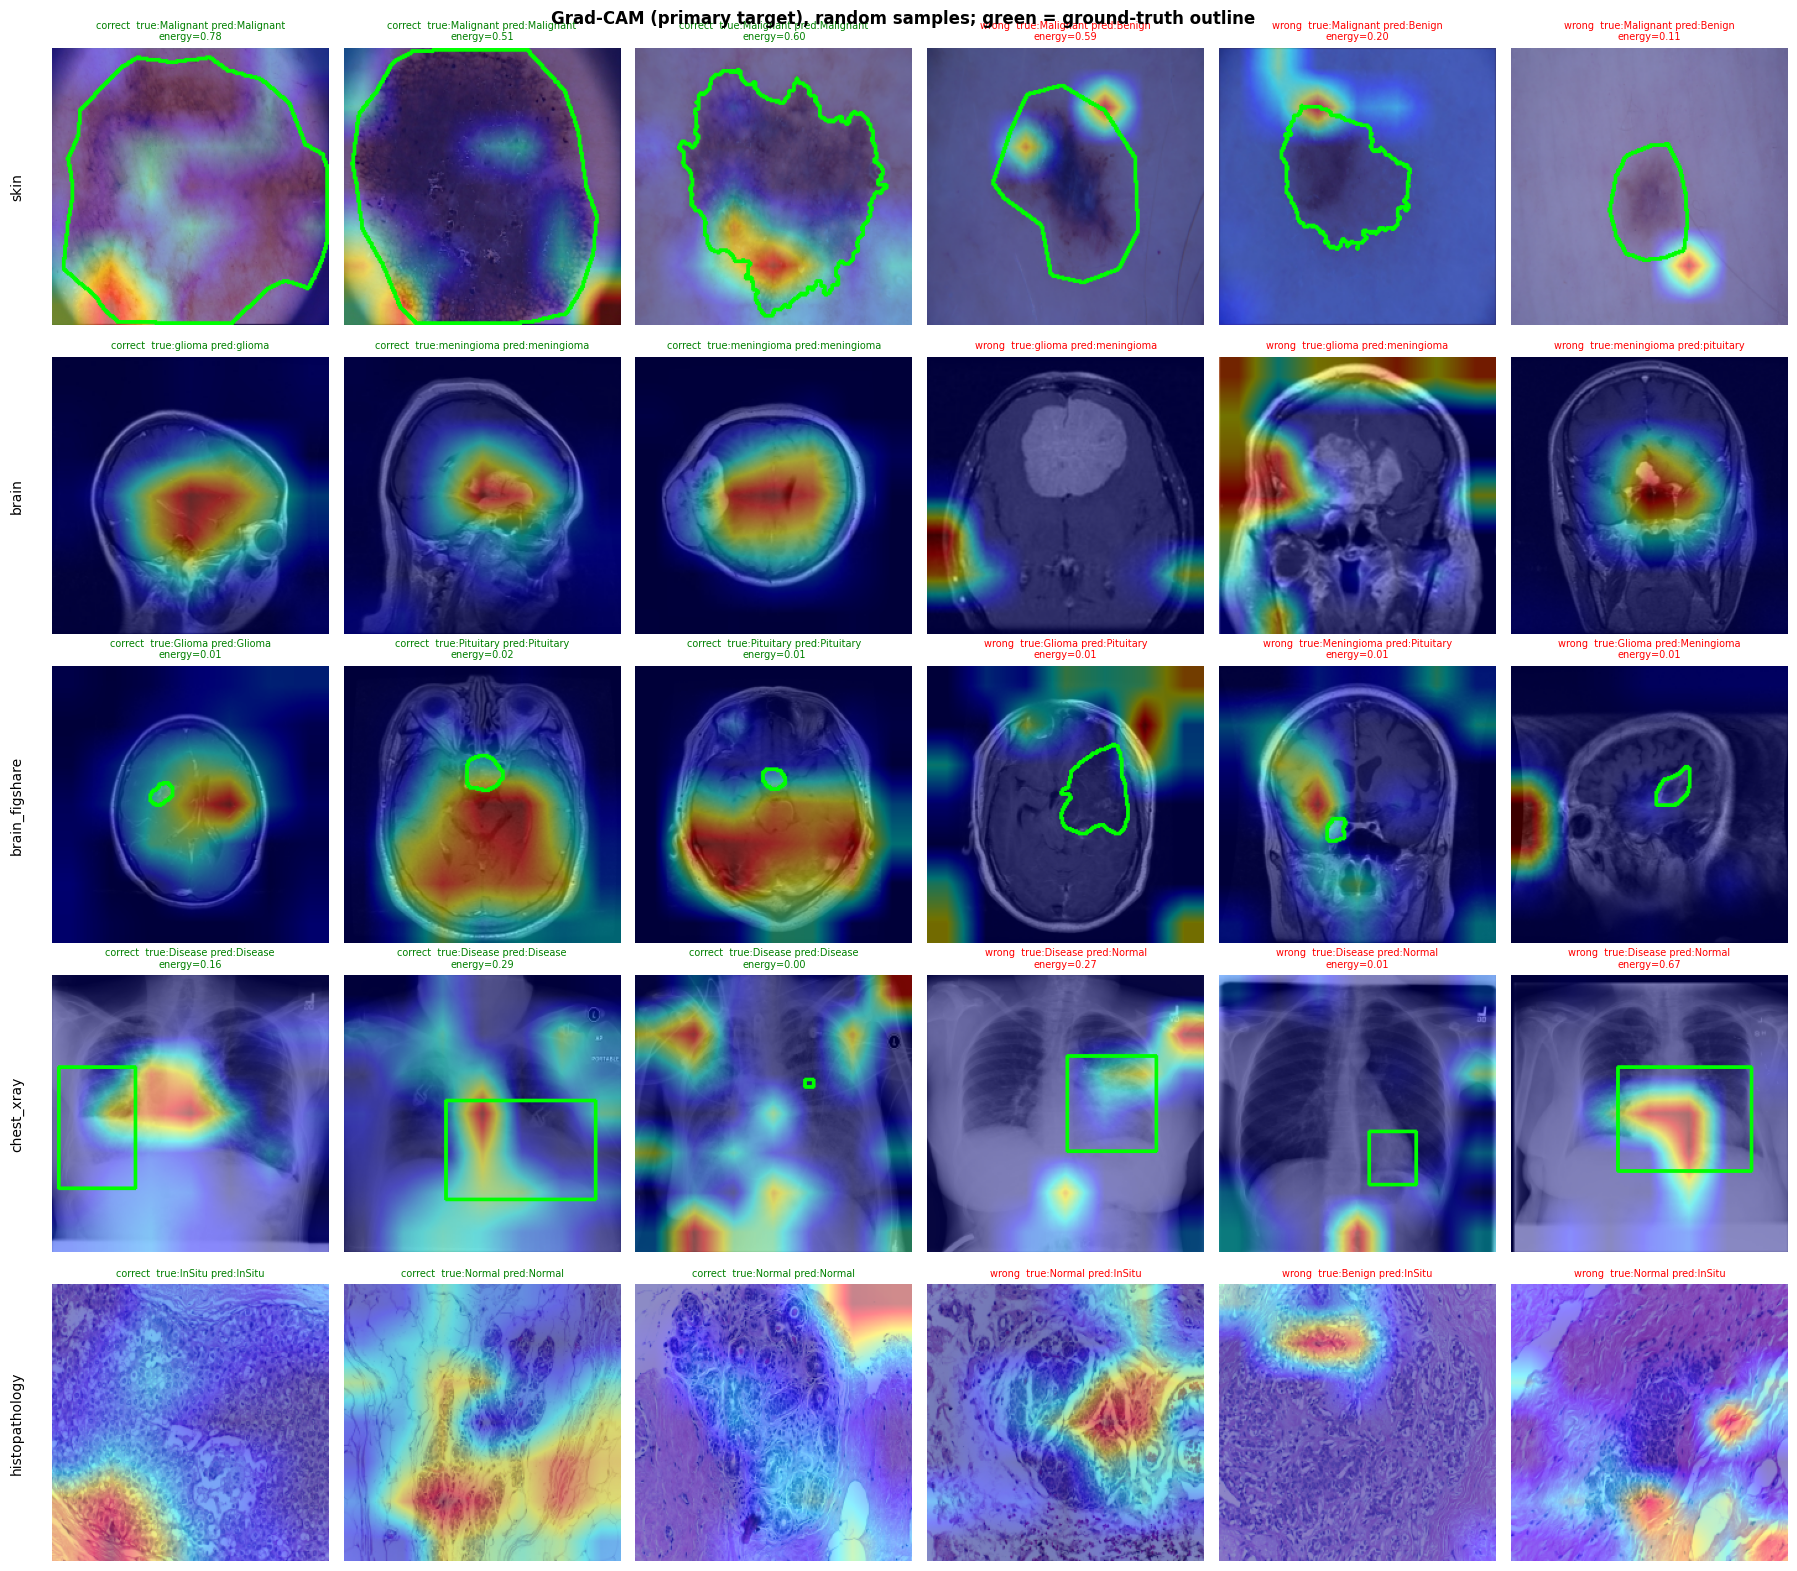

In [37]:
DOMAIN_ORDER = [d for d in ["skin", "brain", "brain_figshare", "chest_xray", "histopathology"] if d in DATA]
PRIMARY = CFG["primary_metric"]

# ---- Fig. A: classification vs baselines --------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(DOMAIN_ORDER))
for i, dname in enumerate(DOMAIN_ORDER):
    if dname not in PAPER: continue
    e = PAPER[dname]["classification"]
    ci = e["ci_first_seed"]["balanced_accuracy"]
    ax.errorbar(i, e["balanced_accuracy"]["mean"], yerr=[[e["balanced_accuracy"]["mean"] - ci[0]], [ci[1] - e["balanced_accuracy"]["mean"]]],
                fmt="o", color="#4C72B0", capsize=4, label="balanced accuracy (95% CI)" if i == 0 else None)
    ax.plot(i, e["accuracy"]["mean"], "s", color="#999999", label="accuracy" if i == 0 else None)
    ax.hlines(e["chance_balanced_acc"], i - 0.3, i + 0.3, colors="r", linestyles=":", label="chance" if i == 0 else None)
    ax.hlines(e["majority_baseline_acc"], i - 0.3, i + 0.3, colors="k", linestyles="--", label="majority-class accuracy" if i == 0 else None)
ax.set_xticks(x); ax.set_xticklabels(DOMAIN_ORDER); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
ax.set_title("Test classification performance vs. baselines (domains in qualitative order)")
ax.legend(fontsize=8, loc="lower left"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figA_classification.png"), dpi=200); plt.show()

# ---- Fig. B: localisation, correct vs misclassified, class-conditioned, primary target ----------
def load_loc(dname, seed):
    f = os.path.join(domain_dir(dname, seed), "localisation_per_sample.csv")
    return pd.read_csv(f) if os.path.exists(f) else None

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, dname in enumerate(DOMAIN_ORDER):
    D = DATA[dname]; loc = load_loc(dname, SEEDS[0])
    if loc is None:
        ax.text(i, 0.5, "not evaluated\n(no localisation GT)", ha="center", va="center", fontsize=8, color="gray")
        continue
    pos = D.get("positive_class")
    sub = loc if pos is None else loc[loc["label"] == pos]
    prim = sub[sub["target"] == primary_target_name(D)]
    base = sub[sub["target"] == "centre_prior_baseline"]
    for off, flag, col, lab in ((-0.15, 1, "#4C72B0", "correct"), (0.15, 0, "#C44E52", "misclassified")):
        v = prim.loc[prim["correct"] == flag, PRIMARY].dropna().values
        if len(v) == 0: continue
        bm = boot_stat(v, np.mean, 5000, np.random.default_rng(0))
        lo, hi = np.percentile(bm, [2.5, 97.5])
        ax.errorbar(i + off, v.mean(), yerr=[[v.mean() - lo], [hi - v.mean()]], fmt="o", color=col, capsize=4,
                    label=None)
        ax.scatter(np.full(len(v), i + off) + np.random.default_rng(1).uniform(-0.05, 0.05, len(v)), v, s=6, alpha=0.25, color=col)
        ax.text(i + off, -0.06, f"n={len(v)}", ha="center", fontsize=7)
    ax.hlines(base[PRIMARY].mean(), i - 0.35, i + 0.35, colors="k", linestyles="--")
    ax.hlines(prim["gt_area_frac"].mean(), i - 0.35, i + 0.35, colors="gray", linestyles=":")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], marker="o", color="#4C72B0", ls="", label="correct"),
                   Line2D([], [], marker="o", color="#C44E52", ls="", label="misclassified"),
                   Line2D([], [], color="k", ls="--", label="centre-prior baseline"),
                   Line2D([], [], color="gray", ls=":", label="uniform-map level (GT area)")], fontsize=8)
ax.set_xticks(np.arange(len(DOMAIN_ORDER))); ax.set_xticklabels(DOMAIN_ORDER); ax.set_ylim(-0.1, 1)
ax.set_ylabel(f"{PRIMARY} (primary target)"); ax.grid(alpha=0.3)
ax.set_title("Grad-CAM energy inside ground truth, within the positive class (TP vs FN)")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figB_localisation.png"), dpi=200); plt.show()

# ---- Fig. C: threshold sensitivity of delta IoU (reviewer #6) -----------------------------------
gt_domains = [dn for dn in DOMAIN_ORDER if load_loc(dn, SEEDS[0]) is not None]
if gt_domains:
    fig, axes = plt.subplots(1, len(gt_domains), figsize=(5.5 * len(gt_domains), 4), squeeze=False)
    for ax, dname in zip(axes[0], gt_domains):
        D = DATA[dname]
        st = pd.read_csv(os.path.join(domain_dir(dname, SEEDS[0]), "localisation_stats.csv"))
        pos = D.get("positive_class")
        subset = f"true={D['class_names'][pos]}" if pos is not None else "all_classes"
        for target, col in ((primary_target_name(D), "#2A9D8F"), ("predicted_logit", "#E76F51"), ("predicted_prob_legacy", "#999999")):
            s = st[(st["target"] == target) & (st["subset"] == subset) & (st["zero_maps"] == "include_zero_maps")
                   & st["metric"].str.startswith("iou@")]
            if "delta_mean" not in s or s["delta_mean"].isna().all(): continue
            taus = [float(m.split("@")[1]) for m in s["metric"]]
            ci = np.array([json.loads(c) if isinstance(c, str) else [np.nan, np.nan] for c in s["delta_mean_ci"]])
            ax.plot(taus, s["delta_mean"], "o-", color=col, label=target)
            ax.fill_between(taus, ci[:, 0], ci[:, 1], color=col, alpha=0.15)
        ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("threshold tau"); ax.set_ylabel("delta IoU (M - C)")
        ax.set_title(f"{dname}: {subset}"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figC_threshold_sensitivity.png"), dpi=200); plt.show()

# ---- Fig. D: confusion matrices (counts + row %) from predictions_test.csv ----------------------
fig, axes = plt.subplots(1, len(DOMAIN_ORDER), figsize=(5 * len(DOMAIN_ORDER), 4.3), squeeze=False)
for ax, dname in zip(axes[0], DOMAIN_ORDER):
    D = DATA[dname]; K = len(D["class_names"])
    pr = pd.read_csv(os.path.join(domain_dir(dname, SEEDS[0]), "predictions_test.csv"))
    cm = confusion_matrix(pr["label"], pr["pred"], labels=list(range(K)))
    pct = cm / np.maximum(cm.sum(1, keepdims=True), 1) * 100
    annot = np.array([[f"{cm[i, j]}\n({pct[i, j]:.1f}%)" for j in range(K)] for i in range(K)])
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax,
                xticklabels=D["class_names"], yticklabels=D["class_names"])
    ax.set_title(dname); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figD_confusion_matrices.png"), dpi=200); plt.show()

# ---- Fig. E: ROC curves from predictions_test.csv -----------------------------------------------
fig, axes = plt.subplots(1, len(DOMAIN_ORDER), figsize=(5 * len(DOMAIN_ORDER), 4.3), squeeze=False)
for ax, dname in zip(axes[0], DOMAIN_ORDER):
    D = DATA[dname]; pr = pd.read_csv(os.path.join(domain_dir(dname, SEEDS[0]), "predictions_test.csv"))
    ks = [D["positive_class"]] if len(D["class_names"]) == 2 else range(len(D["class_names"]))
    for k in ks:
        c = D["class_names"][k]; y = (pr["label"] == k).astype(int)
        fpr, tpr, _ = roc_curve(y, pr[f"prob_{c}"])
        ax.plot(fpr, tpr, label=f"{c} (AUC={roc_auc_score(y, pr[f'prob_{c}']):.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_title(dname); ax.legend(fontsize=7, loc="lower right")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figE_roc.png"), dpi=200); plt.show()

# ---- Fig. F: Grad-CAM examples: RANDOM TP/FN (positive class), GT contour, primary target -------
def overlay(img_0_255, cam, gt=None):
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    out = np.uint8(0.55 * img_0_255 + 0.45 * heat)
    if gt is not None:
        cnts, _ = cv2.findContours(gt.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, (0, 255, 0), 2)
    return out

rows = [dn for dn in DOMAIN_ORDER]
fig, axes = plt.subplots(len(rows), 6, figsize=(18, 3.2 * len(rows)), squeeze=False)
rng = np.random.default_rng(SPLIT_SEED)
for r_i, dname in enumerate(rows):
    D = DATA[dname]; pr = pd.read_csv(os.path.join(domain_dir(dname, SEEDS[0]), "predictions_test.csv"))
    pos = D.get("positive_class")
    pool = pr if pos is None else pr[pr["label"] == pos]
    if (pool["gt_type"] != "none").any():
        pool = pool[pool["gt_type"] != "none"]
    picks = []
    for flag in (1, 0):
        cand = pool[pool["correct"] == flag]
        picks += [(r, flag) for _, r in cand.sample(min(3, len(cand)), random_state=int(rng.integers(1_000_000))).iterrows()]
    tf.keras.backend.clear_session(); model = load_trained_model(D, SEEDS[0]); cam_model = make_cam_model(model)
    man = D["manifest"].set_index("path")
    for j in range(6):
        ax = axes[r_i, j]; ax.axis("off")
        if j >= len(picks): continue
        r, flag = picks[j]
        img = read_image_rgb(r["path"])
        maps, _ = gradcam_all_targets(cam_model, img, D, r["label"])
        cam, _ = maps[primary_target_name(D)]
        mrow = man.loc[r["path"]]; gt = load_gt_mask(mrow) if mrow["gt_type"] != "none" else None
        ax.imshow(overlay(img, cam, gt))
        extra = f"\nenergy={localisation_metrics(cam, gt, [0.5])['energy_in_gt']:.2f}" if gt is not None else ""
        ax.set_title(f"{'correct' if flag else 'wrong'}  true:{D['class_names'][int(r['label'])]} "
                     f"pred:{D['class_names'][int(r['pred'])]}{extra}", fontsize=7, color="green" if flag else "red")
    axes[r_i, 0].text(-0.1, 0.5, dname, transform=axes[r_i, 0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
    del model, cam_model
plt.suptitle("Grad-CAM (primary target), random samples; green = ground-truth outline", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figF_gradcam_examples.png"), dpi=150); plt.show()

## Cell 13 — Before you rewrite the paper: interpretation rules and reviewer checklist

**Decision rule for the "failure mode" claim (write it in Methods *before* reading the results):**
* The claim "errors occur despite lesion-focused attribution" needs, in the positive class and with the **fixed** target: Δ energy-in-GT > 0 with a 95 % CI excluding 0, misclassified energy above the centre-prior baseline, and the same sign across τ = 0.3–0.7.
* If Δ is only positive with the predicted-class target, it is a target artefact, not a finding.
* If both correct and misclassified maps sit at or below the centre-prior baseline, the model is not localising lesions in either group — report that honestly; it is still a publishable, useful negative result about Grad-CAM on ImageNet-transferred models.

| Reviewer point | Where it is handled |
|---|---|
| 1 Dataset counts | Cells 3–4: header-safe CSV, computed Table 1, assertions |
| 2 Fig. 4 caption vs Table 3 | Cell 11 `caption_facts.txt`; Fig. D shows counts + row % |
| 3 Class-target confound | Cell 8 fixed target (primary) vs predicted target (secondary) |
| 4 No statistics | Cell 9 bootstrap CIs, Mann–Whitney, permutation, Cliff's δ, Holm |
| 5 24.4× exaggerates | Ratio demoted; absolute means + Δ with CI reported; centre-prior baseline |
| 6 Threshold sensitivity | Cell 8/9 τ = 0.3–0.7 + threshold-free energy & pointing; Fig. C |
| 7 Missing plotted as zero | Fig. B writes "not evaluated" |
| 8 Four-domain framing | Paper text: 4 classification + 2 (or 3 with figshare) localisation domains |
| 9 ChestX-ray14 subset | Cell 3 patient-level split, bbox patients forced to test, exclusion log |
| 10 BACH accounting | Cell 3 stem-duplicate + readability audit, final per-class counts |
| 11 Visual distance ≠ cause | Wording: descriptive association; optionally measure FID/feature distance |
| 12 AUC ≠ confidence | ECE reported; remove "confidence" wording |
| 13 Class imbalance | Class-conditioned subsets; balanced accuracy; class weights from train |
| 14–16 Over-claiming | Rewrite Discussion/Conclusion after the new numbers exist |
| Minor: seeds, versions, optimizer, checkpoint, logits, interpolation | `run_config.json`, `train_info.json`, Cells 2, 5, 6, 8 |
| Minor: "uploadsoononKaggle" | Upload `manifest_*.csv` + code to Zenodo/GitHub release with DOI |

## Cell 14 — Final paper numbers + corrected Fig. 2
**Reads:** `metrics.json`, `localisation_stats.csv`, `localisation_per_sample.csv` (from Cell 10)
**Writes:** `table6b_border_by_class.csv`, `table7_medians_pointing.csv`, `figA_classification.png`
**Used in paper:** Table 3 (AUC and macro-F1 SDs), Table 4 (baselines and pointing game),
Table 6 (border attention by class), Fig. 2.
**Must run AFTER Cell 12**, because Cell 12 overwrites Fig. 2 with the old version.

FIX 1 - CLASSIFICATION (mean ± SD over seeds)
  skin            seeds=3 | bal.acc 0.619 ± 0.046 | AUC 0.698 ± 0.039 | macro-F1 0.615 ± 0.027
  brain           seeds=3 | bal.acc 0.939 ± 0.007 | AUC 0.987 ± 0.002 | macro-F1 0.938 ± 0.007
  chest_xray      seeds=3 | bal.acc 0.636 ± 0.007 | AUC 0.680 ± 0.004 | macro-F1 0.636 ± 0.007
  histopathology  seeds=3 | bal.acc 0.794 ± 0.050 | AUC 0.925 ± 0.029 | macro-F1 0.769 ± 0.059
  brain_figshare  seeds=3 | bal.acc 0.880 ± 0.018 | AUC 0.974 ± 0.007 | macro-F1 0.868 ± 0.017

FIX 2 - BORDER ATTENTION by true class:
         domain  seed true_class  uniform  n_C  n_M  mean_C  mean_M  delta                                     delta_ci     p                                        note
          skin    42     Benign    0.334  225   66   0.330   0.205 -0.126  [-0.18168451230649182, -0.0703060666312557] 0.007                                            
          skin    42  Malignant    0.318   42   33   0.180   0.314  0.134   [0.04761122327248849, 0

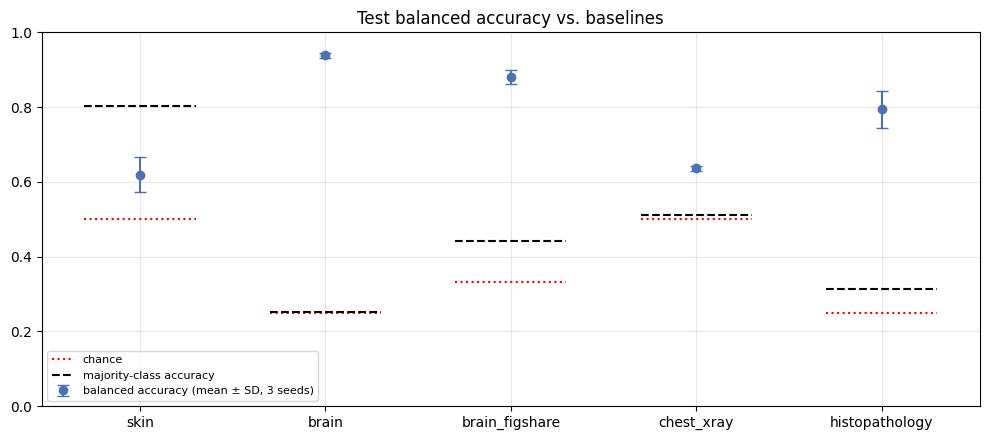


Saved: table6b_border_by_class.csv, table7_medians_pointing.csv, figA_classification.png


In [15]:
# ===================== FIX 1-3 + new Fig. 2 (reads saved results only) =====================

# ---- Fix 1: check table (mean ± SD over seeds, nothing mixed)
print("FIX 1 - CLASSIFICATION (mean ± SD over seeds)")
for dname, D in DATA.items():
    runs = [json.load(open(os.path.join(s, "metrics.json"))) for s in seed_dirs(dname)
            if os.path.exists(os.path.join(s, "metrics.json"))]
    ms = lambda v: f"{np.mean(v):.3f} ± {np.std(v, ddof=1):.3f}" if len(v) > 1 else f"{v[0]:.3f}"
    print(f"  {dname:15s} seeds={len(runs)} | bal.acc {ms([r['balanced_accuracy'] for r in runs])} | "
          f"AUC {ms([r['auc'] for r in runs])} | macro-F1 {ms([r['macro_f1'] for r in runs])}")

# ---- Fix 2: border attention split by TRUE CLASS (removes class mixing, senior's point #13)
rows = []
for dname, D in DATA.items():
    for s in SEEDS:
        f = os.path.join(domain_dir(dname, s), "localisation_per_sample.csv")
        if not os.path.exists(f): continue
        L = pd.read_csv(f)
        if "energy_border" not in L: continue
        L = L[L["target"] == primary_target_name(D)].dropna(subset=["energy_border"])
        for k, c in enumerate(D["class_names"]):
            S = L[L["label"] == k]
            if len(S) == 0: continue
            r = compare_groups(S.loc[S["correct"] == 0, "energy_border"].values,
                               S.loc[S["correct"] == 1, "energy_border"].values, seed=s)
            rows.append(dict(domain=dname, seed=s, true_class=c, uniform=round(S["border_area_frac"].mean(), 3),
                             n_C=r["n_C"], n_M=r["n_M"], mean_C=r.get("mean_C"), mean_M=r.get("mean_M"),
                             delta=r.get("delta_mean"), delta_ci=r.get("delta_mean_ci"), p=r.get("mwu_p"),
                             note=r.get("note", "")))
bd = pd.DataFrame(rows)
bd.to_csv(os.path.join(OUTPUT_DIR, "table6b_border_by_class.csv"), index=False)
print("\nFIX 2 - BORDER ATTENTION by true class:\n", bd.round(3).to_string(index=False))

# ---- Fix 3: medians + pointing game, with exact centre-prior and uniform baselines
rows = []
for dname, D in DATA.items():
    pos = D.get("positive_class")
    subset = f"true={D['class_names'][pos]}" if pos is not None else "all_classes"
    for s in SEEDS:
        fs = os.path.join(domain_dir(dname, s), "localisation_stats.csv")
        fl = os.path.join(domain_dir(dname, s), "localisation_per_sample.csv")
        if not os.path.exists(fs): continue
        st, L = pd.read_csv(fs), pd.read_csv(fl)
        Lb = L[L["target"] == "centre_prior_baseline"]
        Lp = L[L["target"] == primary_target_name(D)]
        if pos is not None:
            Lb, Lp = Lb[Lb["label"] == pos], Lp[Lp["label"] == pos]
        for metric in ("energy_in_gt", "pointing_hit"):
            r = st[(st["target"] == primary_target_name(D)) & (st["subset"] == subset) &
                   (st["zero_maps"] == "include_zero_maps") & (st["metric"] == metric)].iloc[0]
            rows.append(dict(domain=dname, seed=s, metric=metric, n_C=r["n_C"], n_M=r["n_M"],
                             median_C=r.get("median_C"), median_M=r.get("median_M"),
                             mean_C=r.get("mean_C"), mean_M=r.get("mean_M"), mwu_p=r.get("mwu_p"),
                             centre_prior=round(Lb[metric].mean(), 3),
                             uniform_level=round(Lp["gt_area_frac"].mean(), 3) if metric == "energy_in_gt" else None))
pg = pd.DataFrame(rows)
pg.to_csv(os.path.join(OUTPUT_DIR, "table7_medians_pointing.csv"), index=False)
print("\nFIX 3 - MEDIANS, POINTING GAME, BASELINES:\n", pg.round(3).to_string(index=False))

# ---- New Fig. 2: mean ± SD over seeds (replaces the mixed-CI version)
DOMAIN_ORDER = [d for d in ["skin", "brain", "brain_figshare", "chest_xray", "histopathology"] if d in DATA]
fig, ax = plt.subplots(figsize=(10, 4.5))
for i, d in enumerate(DOMAIN_ORDER):
    runs = [json.load(open(os.path.join(s, "metrics.json"))) for s in seed_dirs(d)]
    b = [r["balanced_accuracy"] for r in runs]
    ax.errorbar(i, np.mean(b), yerr=np.std(b, ddof=1), fmt="o", color="#4C72B0", capsize=4,
                label="balanced accuracy (mean ± SD, 3 seeds)" if i == 0 else None)
    ax.hlines(1 / len(DATA[d]["class_names"]), i - .3, i + .3, colors="r", linestyles=":",
              label="chance" if i == 0 else None)
    ax.hlines(runs[0]["majority_baseline_acc"], i - .3, i + .3, colors="k", linestyles="--",
              label="majority-class accuracy" if i == 0 else None)
ax.set_xticks(range(len(DOMAIN_ORDER))); ax.set_xticklabels(DOMAIN_ORDER); ax.set_ylim(0, 1)
ax.grid(alpha=.3); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Test balanced accuracy vs. baselines")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "figA_classification.png"), dpi=200); plt.show()
print("\nSaved: table6b_border_by_class.csv, table7_medians_pointing.csv, figA_classification.png")